#Import Datasets#

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [ ]:
itac = pd.read_csv('/content/drive/MyDrive/WhisperData/itac_compact.csv')
sic = pd.read_csv('/content/drive/MyDrive/WhisperData/sic-codes.csv')

In [ ]:
itac.head()

,ID,CENTER,FY,SIC,NAICS,STATE,ANNUAL_SALES,EMPLOYEES,PLANT_AREA,ANNUAL_ELECTRICITY_COST,...,TOTAL_RECC_SAVINGS,ROI_YRS,PRODUCTS,PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,num_reccs,ARC2,IMPSTATUS
0,AM0001,AM,1987,3671.0,NaN,TX,33900000.0,206.0,NaN,184985.0,...,4479.0,3.562402,MICRO & MINI COMPUTERS,1.0,310.0,2250.0,7,7,"2.8114,2.7142,2.7111,2.7447,2.7233,2.7111,2.7111","N,N,N,I,N,N,N"
1,AM0002,AM,1987,2761.0,NaN,TX,25000000.0,156.0,NaN,338359.0,...,109532.0,0.672644,BUSINESS FORMS,NaN,NaN,2250.0,9,9,"2.6221,2.7226,2.6212,2.4111,2.7142,2.7142,2.71...","I,I,I,N,I,I,I,I,I"
2,AM0003,AM,1987,3494.0,NaN,TX,15000000.0,200.0,NaN,139480.0,...,16001.0,0.982689,SAFETY JOINTS & VALVES,NaN,NaN,2250.0,8,8,"2.3212,2.7224,2.7111,2.4111,2.7142,2.7142,2.24...","N,N,N,N,N,I,N,I"
3,AM0004,AM,1987,3713.0,NaN,TX,4200000.0,75.0,NaN,68986.0,...,17607.0,1.273868,TRUCKS BEDS & TRAILERS,1.0,1000.0,2340.0,11,11,"2.6218,2.7142,2.7142,2.4236,2.7142,2.6232,2.62...","I,I,I,I,N,N,N,I,N,N,N"
4,AM0005,AM,1987,2024.0,NaN,TX,12000000.0,39.0,NaN,185065.0,...,3402.0,2.190770,ICE CREAM,5.0,2000.0,2080.0,7,7,"2.7142,2.7142,2.7142,2.2449,2.4111,2.1233,2.8112","I,I,N,N,N,I,N"


In [ ]:
sic.head()

,Division,Major Group,Industry Group,SIC,Description
0,A,1,11,111,Wheat
1,A,1,11,112,Rice
2,A,1,11,115,Corn
3,A,1,11,116,Soybeans
4,A,1,11,119,"Cash Grains, Not Elsewhere Classified"


In [ ]:
itac['SIC'] = itac['SIC'].astype('Int64')
sic['SIC']  = sic['SIC'].astype('Int64')
df = pd.merge(
    itac,
    sic,
    on='SIC',
    how='left',
    validate='many_to_one'
)
df.head()

,ID,CENTER,FY,SIC,NAICS,STATE,ANNUAL_SALES,EMPLOYEES,PLANT_AREA,ANNUAL_ELECTRICITY_COST,...,PRODLEVEL,PRODHOURS,NUMARS,num_reccs,ARC2,IMPSTATUS,Division,Major Group,Industry Group,Description
0,AM0001,AM,1987,3671,NaN,TX,33900000.0,206.0,NaN,184985.0,...,310.0,2250.0,7,7,"2.8114,2.7142,2.7111,2.7447,2.7233,2.7111,2.7111","N,N,N,I,N,N,N",D,36.0,367.0,Electron Tubes
1,AM0002,AM,1987,2761,NaN,TX,25000000.0,156.0,NaN,338359.0,...,NaN,2250.0,9,9,"2.6221,2.7226,2.6212,2.4111,2.7142,2.7142,2.71...","I,I,I,N,I,I,I,I,I",D,27.0,276.0,Manifold Business Forms
2,AM0003,AM,1987,3494,NaN,TX,15000000.0,200.0,NaN,139480.0,...,NaN,2250.0,8,8,"2.3212,2.7224,2.7111,2.4111,2.7142,2.7142,2.24...","N,N,N,N,N,I,N,I",D,34.0,349.0,"Valves and Pipe Fittings, Not Elsewhere Classi..."
3,AM0004,AM,1987,3713,NaN,TX,4200000.0,75.0,NaN,68986.0,...,1000.0,2340.0,11,11,"2.6218,2.7142,2.7142,2.4236,2.7142,2.6232,2.62...","I,I,I,I,N,N,N,I,N,N,N",D,37.0,371.0,Truck and Bus Bodies
4,AM0005,AM,1987,2024,NaN,TX,12000000.0,39.0,NaN,185065.0,...,2000.0,2080.0,7,7,"2.7142,2.7142,2.7142,2.2449,2.4111,2.1233,2.8112","I,I,N,N,N,I,N",D,20.0,202.0,Ice Cream and Frozen Desserts


In [ ]:
df.columns

Index(['ID', 'CENTER', 'FY', 'SIC', 'NAICS', 'STATE', 'ANNUAL_SALES',
       'EMPLOYEES', 'PLANT_AREA', 'ANNUAL_ELECTRICITY_COST',
       'TOTAL_RECC_IMP_COST', 'TOTAL_RECC_SAVINGS', 'ROI_YRS', 'PRODUCTS',
       'PRODUNITS', 'PRODLEVEL', 'PRODHOURS', 'NUMARS', 'num_reccs', 'ARC2',
       'IMPSTATUS', 'Division', 'Major Group', 'Industry Group',
       'Description'],
      dtype='object')

In [ ]:
df.shape

(22134, 25)

#Data Filtering and Sector Independent Analysis#

In [ ]:
df = df[
    (df['FY']>=2018)&
    (df['ANNUAL_ELECTRICITY_COST'] > 100_000) &
    (df['ANNUAL_ELECTRICITY_COST'] < 3_000_000) &
    (df['TOTAL_RECC_SAVINGS']    >= 100_000) &
    (df['ROI_YRS']              <=   5)
].copy()

df.shape


(1041, 25)

In [ ]:
df.describe()

,FY,SIC,NAICS,ANNUAL_SALES,EMPLOYEES,PLANT_AREA,ANNUAL_ELECTRICITY_COST,TOTAL_RECC_IMP_COST,TOTAL_RECC_SAVINGS,ROI_YRS,PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,num_reccs,Major Group,Industry Group
count,1041.000000,1041.0,1041.000000,1.041000e+03,1041.000000,1.041000e+03,1.041000e+03,1.041000e+03,1.041000e+03,1041.000000,627.000000,1.041000e+03,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000
mean,2021.809798,3316.463977,323834.390010,7.404256e+07,182.426513,3.781015e+05,1.047491e+06,5.569070e+05,3.045581e+05,1.935829,2.730463,2.406518e+08,6357.924111,7.831892,7.831892,32.629203,331.216138
std,2.217140,1052.378384,61280.980511,1.271790e+08,179.088699,1.094804e+06,7.658927e+05,7.793206e+05,3.598968e+05,1.346706,1.574278,3.378809e+09,2229.937969,2.842937,2.842937,10.567952,105.288662
min,2018.000000,161.0,32541.000000,8.000000e+04,1.000000,3.300000e+03,1.003840e+05,3.781100e+03,1.002690e+05,0.011957,1.000000,1.000000e+00,1188.000000,3.000000,3.000000,1.000000,16.000000
25%,2020.000000,2672.0,312120.000000,1.700000e+07,60.000000,8.000000e+04,4.321760e+05,1.505790e+05,1.348470e+05,0.793991,1.000000,4.645000e+04,4524.000000,6.000000,6.000000,26.000000,267.000000
50%,2022.000000,3351.0,326199.000000,4.000000e+07,120.000000,1.550000e+05,8.102311e+05,3.558240e+05,1.923190e+05,1.633087,2.000000,1.095000e+06,6240.000000,7.000000,7.000000,33.000000,335.000000
75%,2024.000000,3714.0,333996.000000,9.100000e+07,250.000000,3.013000e+05,1.542588e+06,6.793700e+05,3.268860e+05,2.979020,4.500000,1.600000e+07,8736.000000,10.000000,10.000000,37.000000,371.000000
max,2025.000000,8711.0,812332.000000,2.480000e+09,1500.000000,2.178000e+07,2.994775e+06,1.155972e+07,5.196489e+06,4.984380,6.000000,1.000000e+11,8760.000000,19.000000,19.000000,87.000000,871.000000


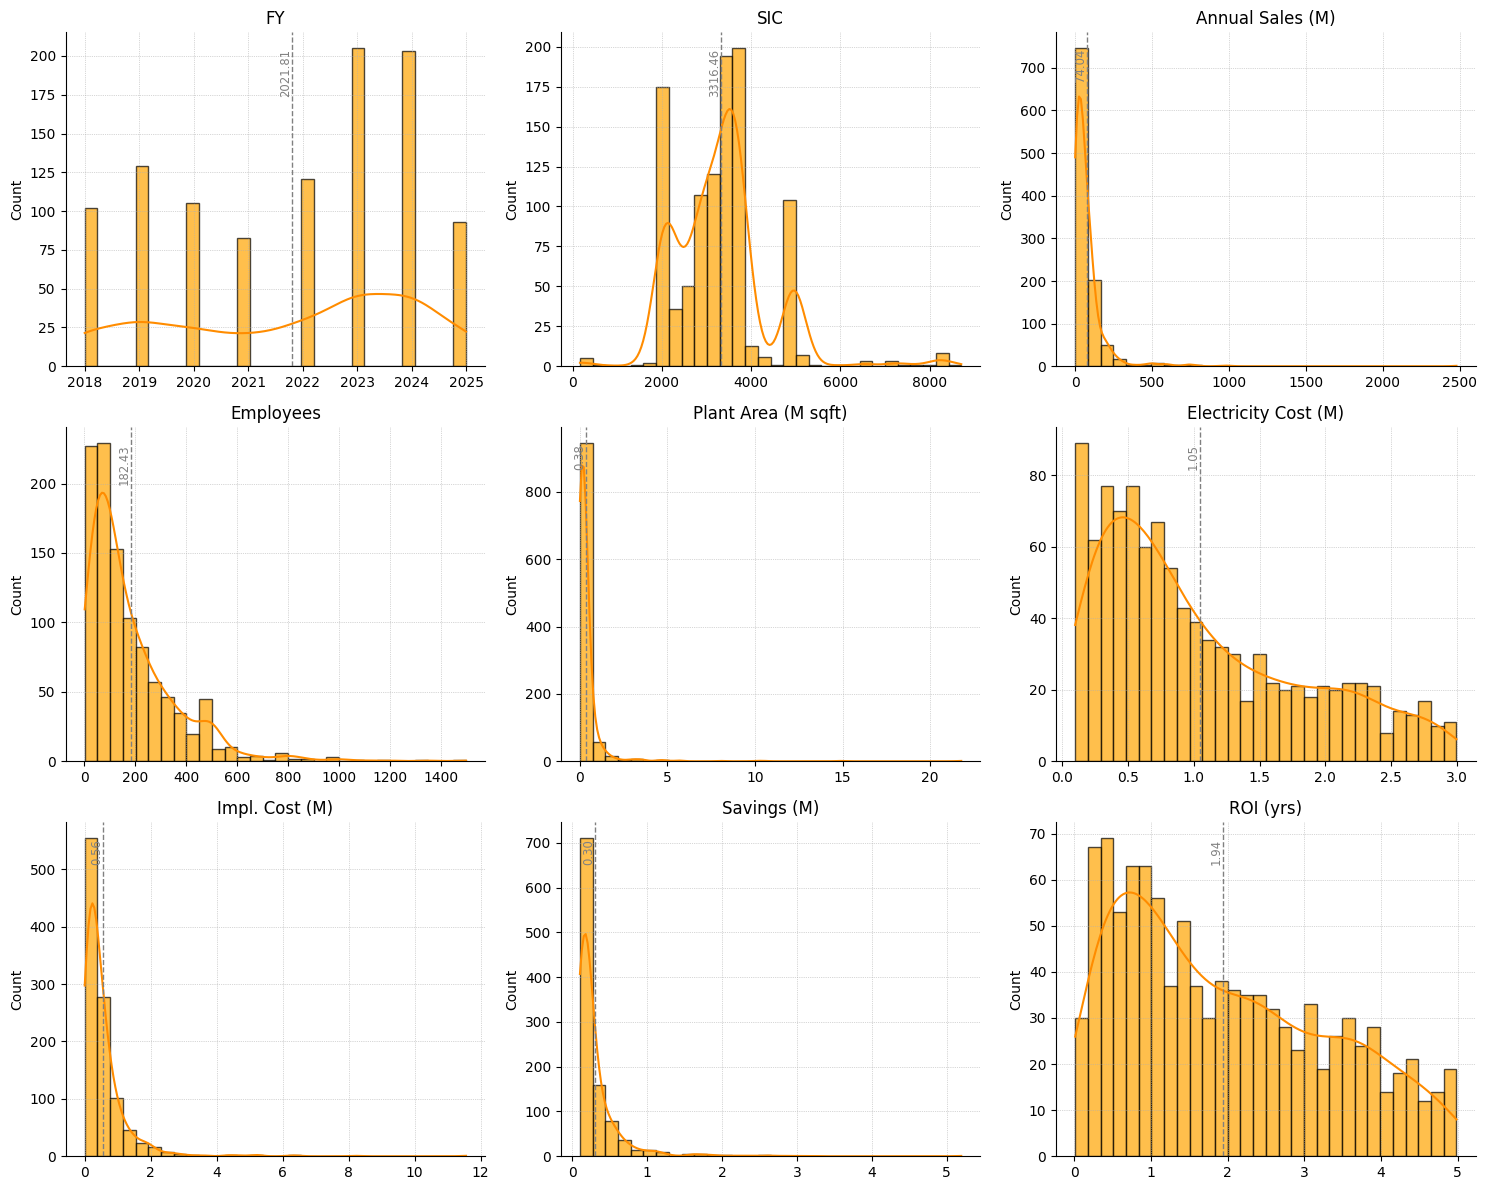

In [ ]:
df_plot = df.copy()
to_mil = [
    'ANNUAL_SALES',
    'ANNUAL_ELECTRICITY_COST',
    'TOTAL_RECC_IMP_COST',
    'TOTAL_RECC_SAVINGS',
    'PLANT_AREA'
]
for col in to_mil:
    df_plot[col] = df_plot[col] / 1e6
df_plot = df_plot.rename(columns={
    'ANNUAL_SALES':            'Annual Sales (M)',
    'ANNUAL_ELECTRICITY_COST': 'Electricity Cost (M)',
    'TOTAL_RECC_IMP_COST':     'Impl. Cost (M)',
    'TOTAL_RECC_SAVINGS':      'Savings (M)',
    'PLANT_AREA':              'Plant Area (M sqft)',
    'EMPLOYEES':               'Employees',
    'ROI_YRS':                 'ROI (yrs)'
})
plot_cols = [
    'FY',
    'SIC',
    'Annual Sales (M)',
    'Employees',
    'Plant Area (M sqft)',
    'Electricity Cost (M)',
    'Impl. Cost (M)',
    'Savings (M)',
    'ROI (yrs)'
]

def hist_with_kde(ax, series):
    data = series.dropna()
    counts, bins, _ = ax.hist(
        data, bins=30, density=False,
        color='orange', edgecolor='black', alpha=0.7
    )
    kde = gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 200)
    bin_w = bins[1] - bins[0]
    ax.plot(xs, kde(xs) * len(data) * bin_w,
            color='darkorange', linewidth=1.5)
    mu = data.mean()
    ax.axvline(mu, linestyle='--', color='gray', linewidth=1)
    y_top = ax.get_ylim()[1]
    ax.text(mu, y_top*0.95, f'{mu:.2f}',
            rotation=90, va='top', ha='right',
            color='gray', fontsize='small')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.5)
    ax.set_ylabel('Count')
    ax.set_xlabel('')
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for ax, col in zip(axes, plot_cols):
    hist_with_kde(ax, df_plot[col])
    ax.set_title(col)
for ax in axes[len(plot_cols):]:
    fig.delaxes(ax)
plt.tight_layout()
plt.show()





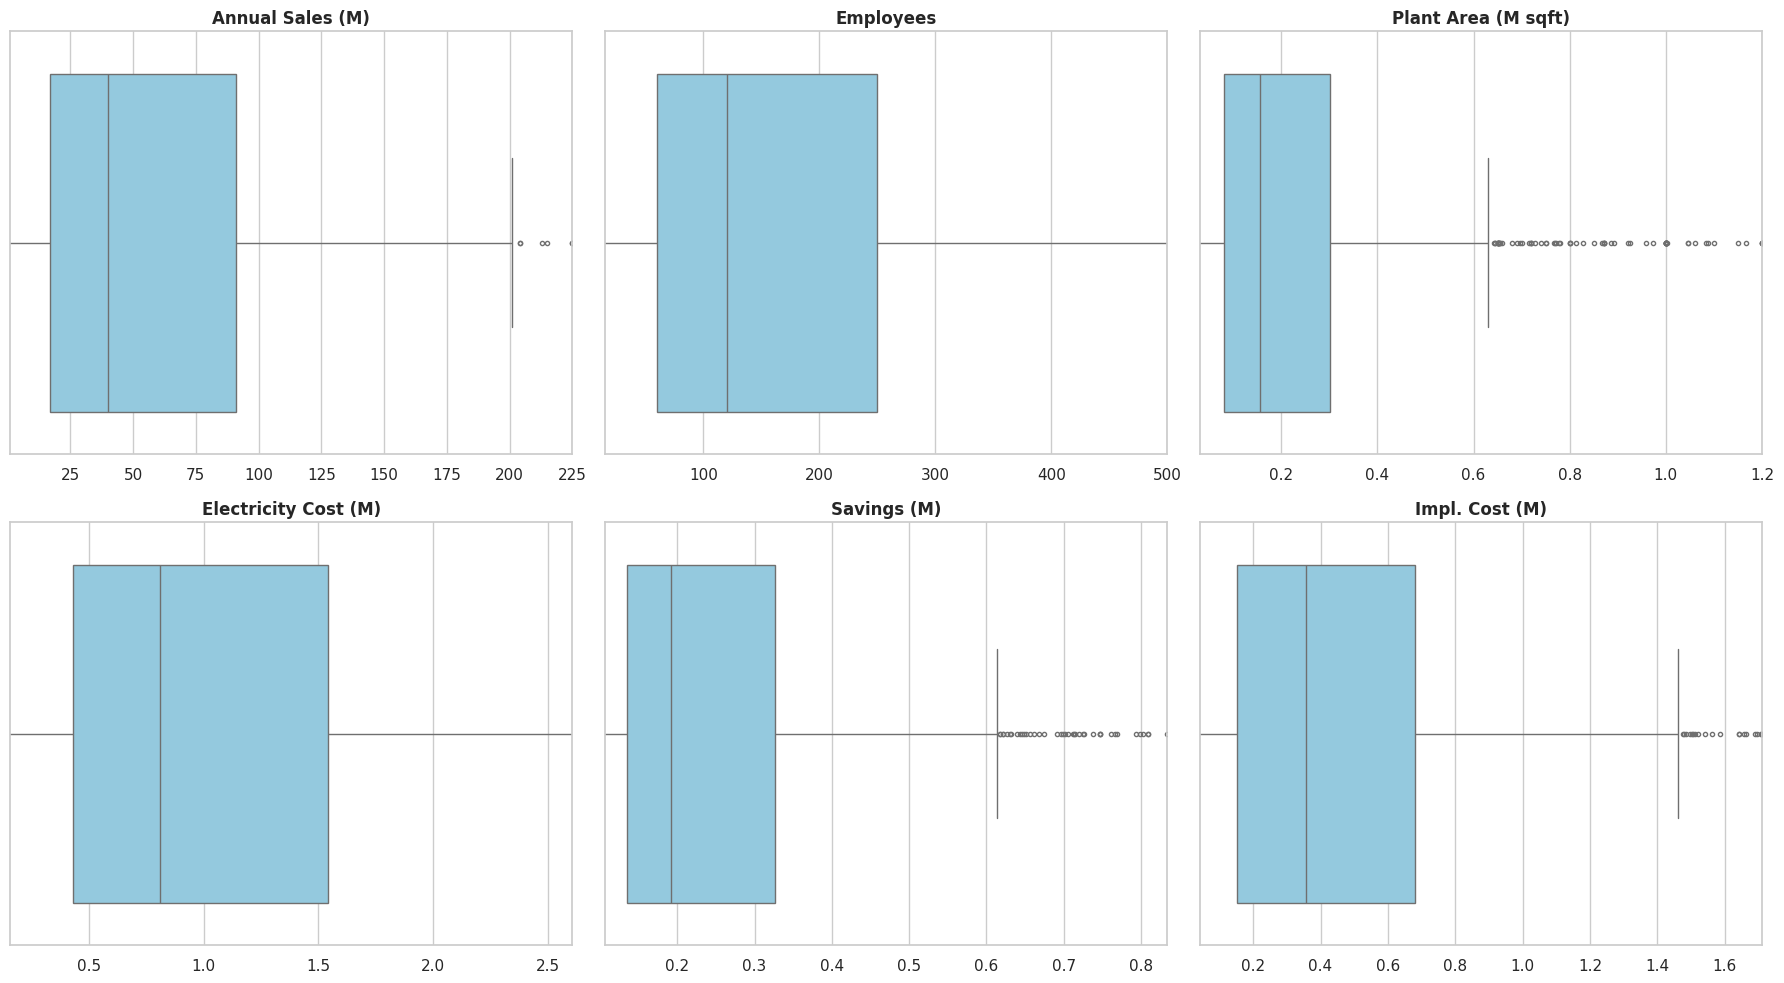

In [ ]:
zoom_cols = [
    'Annual Sales (M)',
    'Employees',
    'Plant Area (M sqft)',
    'Electricity Cost (M)',
    'Savings (M)',
    'Impl. Cost (M)'
]
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, zoom_cols):
    data = df_plot[col].dropna()
    sns.boxplot(x=data, ax=ax, color="skyblue", fliersize=3, linewidth=1)

    # compute 5th & 95th percentiles and set limits
    lower, upper = data.quantile([0.05, 0.95])
    ax.set_xlim(lower, upper)

    ax.set_title(col, fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
for ax in axes[len(zoom_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


Getting the Average Profile

In [ ]:
profile_cols = df_plot.select_dtypes(include='number').columns
avg_series = df_plot[profile_cols].mean()
avg_profile_df = pd.DataFrame([avg_series])
avg_profile_df.index = ['Overall Mean']
avg_profile_df

,FY,SIC,NAICS,Annual Sales (M),Employees,Plant Area (M sqft),Electricity Cost (M),Impl. Cost (M),Savings (M),ROI (yrs),PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,num_reccs,Major Group,Industry Group
Overall Mean,2021.809798,3316.463977,323834.39001,74.042556,182.426513,0.378101,1.047491,0.556907,0.304558,1.935829,2.730463,2.406518e+08,6357.924111,7.831892,7.831892,32.629203,331.216138


#Industry Analysis#

In [ ]:
raw_data = df.copy()
work_data = raw_data.copy()
work_data['AnnualElec(M)'] = work_data['ANNUAL_ELECTRICITY_COST'] / 1e6
work_data['Savings(M)']    = work_data['TOTAL_RECC_SAVINGS']       / 1e6
work_data['ROI(yrs)']      = work_data['ROI_YRS']
sic_lookup = work_data.drop_duplicates('SIC').set_index('SIC')['Description']
sns.set_theme(style="whitegrid")



*Top 10 Major Groups along all dims*

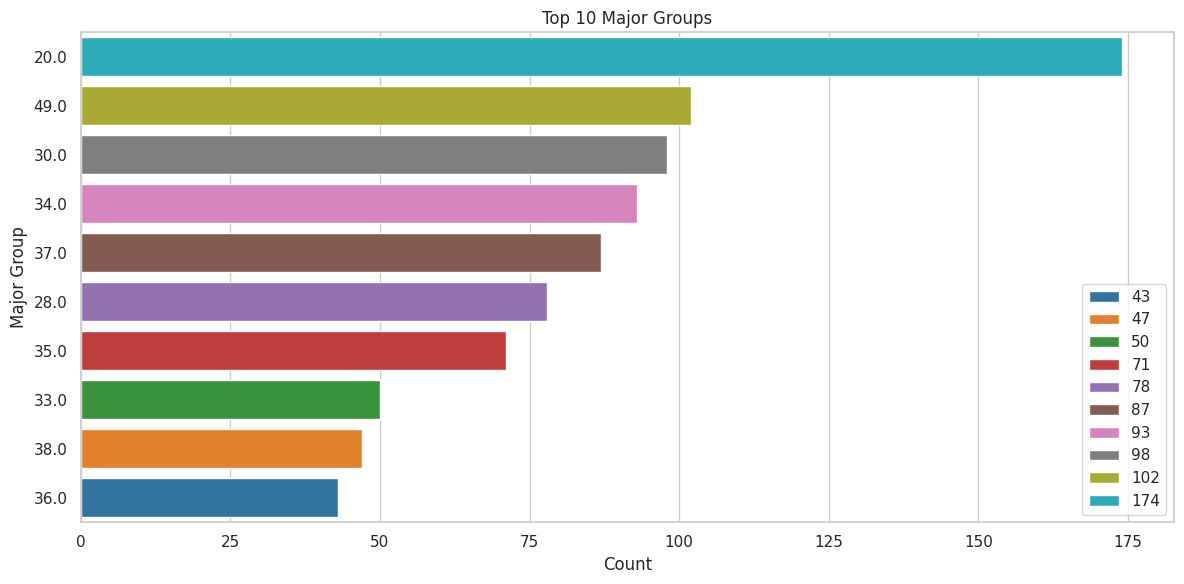

In [ ]:

mg_counts = work_data['Major Group'].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=mg_counts.values, y=mg_counts.index.astype(str),hue=mg_counts.values ,palette='tab10')
plt.title("Top 10 Major Groups")
plt.xlabel("Count")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


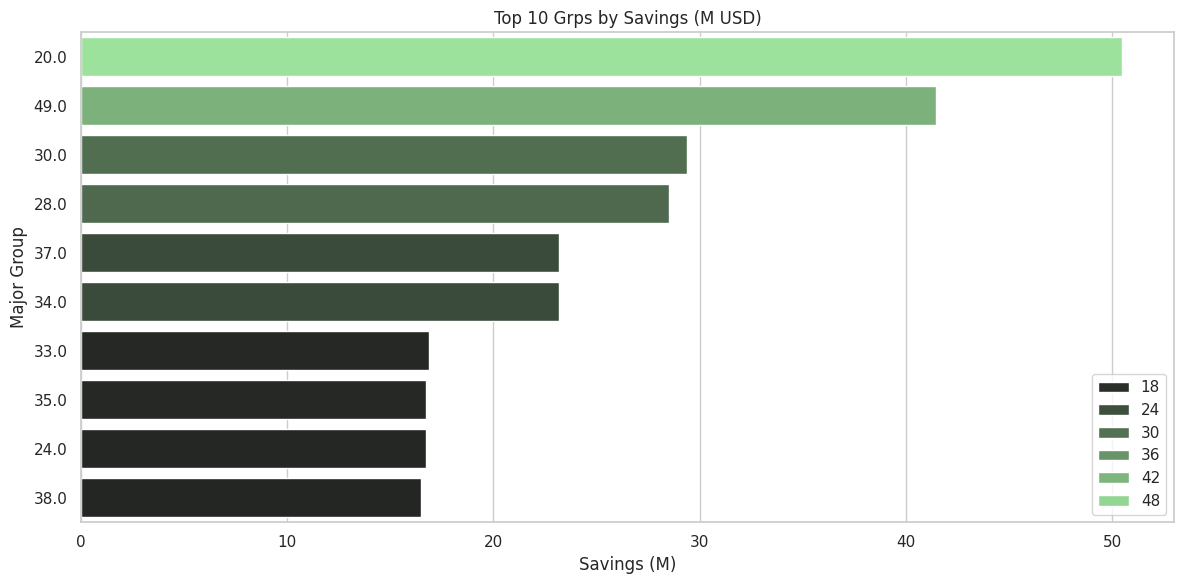

In [ ]:
savings_by_grp = (work_data
                  .groupby('Major Group')['Savings(M)']
                  .sum()
                  .nlargest(10))
plt.figure(figsize=(12,6))
sns.barplot(x=savings_by_grp.values, y=savings_by_grp.index.astype(str),hue = savings_by_grp.values, palette='dark:lightgreen')
plt.title("Top 10 Grps by Savings (M USD)")
plt.xlabel("Savings (M)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()

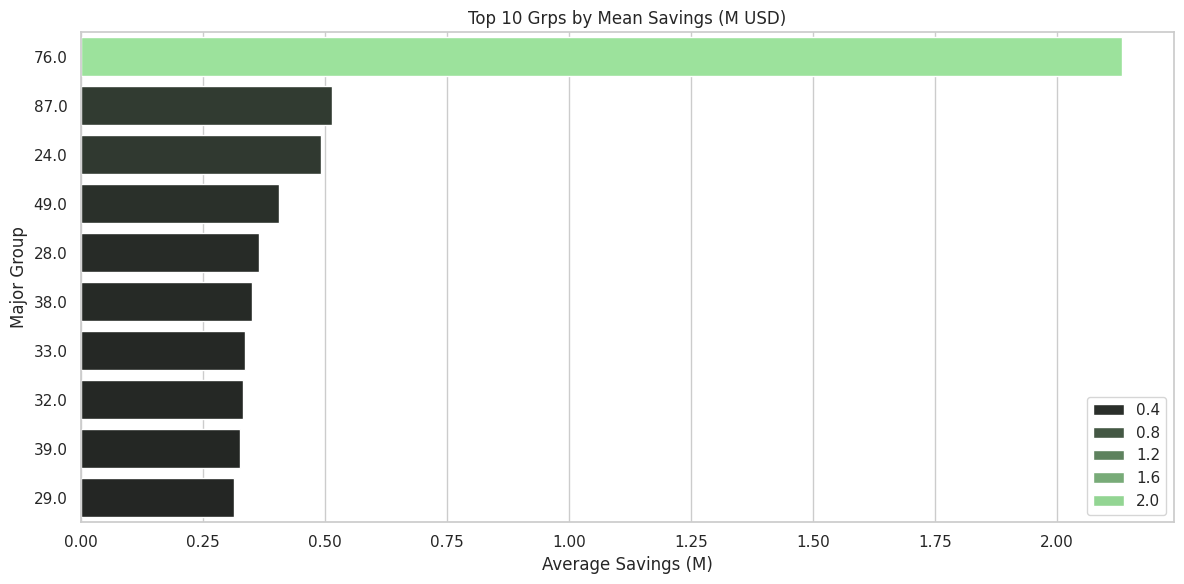

In [ ]:
# 2) Mean Savings
savings_by_grp_mu = (
    work_data
    .groupby('Major Group')['Savings(M)']
    .mean()
    .nlargest(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=savings_by_grp_mu.values,
    y=savings_by_grp_mu.index.astype(str),
    hue=savings_by_grp_mu.values,
    palette='dark:lightgreen'
)
plt.title("Top 10 Grps by Mean Savings (M USD)")
plt.xlabel("Average Savings (M)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


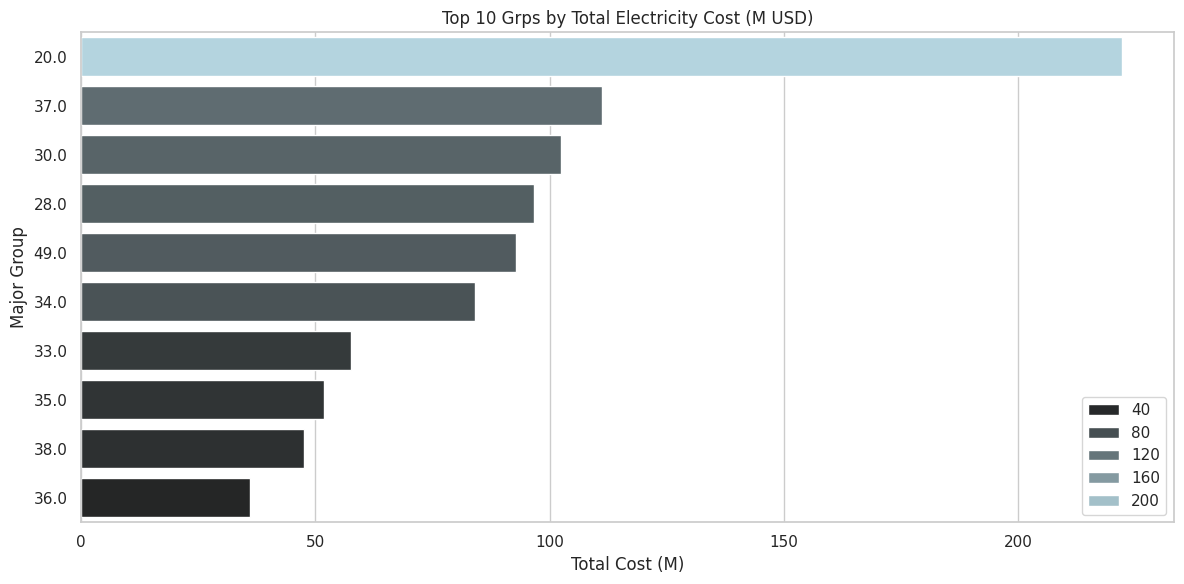

In [ ]:
# 3) Total Electricity Cost
cost_by_grp = (
    work_data
    .groupby('Major Group')['AnnualElec(M)']
    .sum()
    .nlargest(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=cost_by_grp.values,
    y=cost_by_grp.index.astype(str),
    hue=cost_by_grp.values,
    palette='dark:lightblue'
)
plt.title("Top 10 Grps by Total Electricity Cost (M USD)")
plt.xlabel("Total Cost (M)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


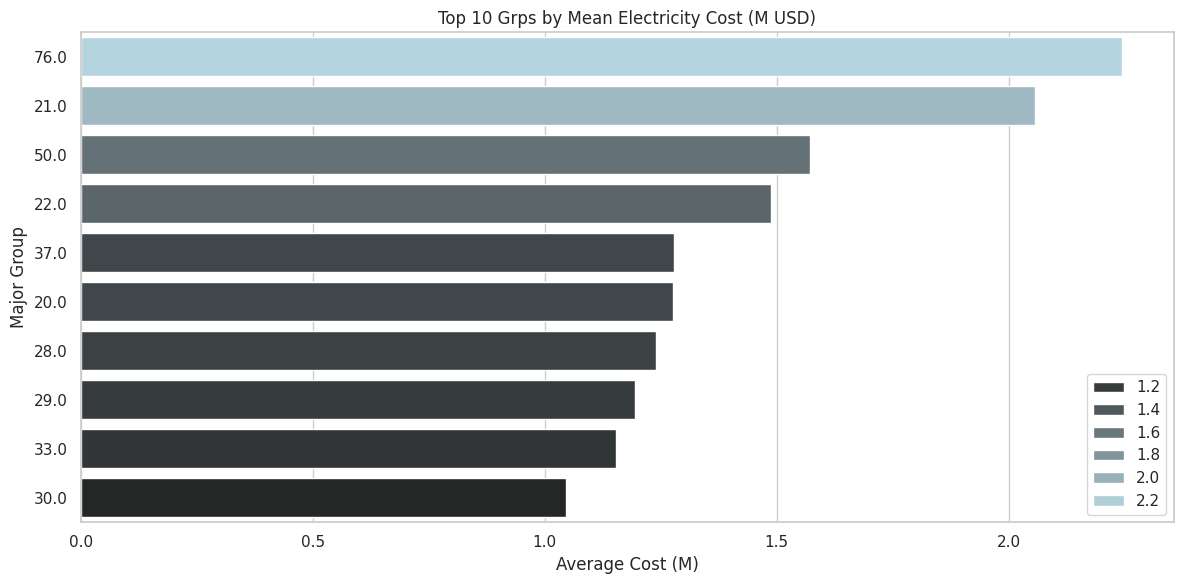

In [ ]:
# 4) Mean Electricity Cost
cost_by_grp_mu = (
    work_data
    .groupby('Major Group')['AnnualElec(M)']
    .mean()
    .nlargest(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=cost_by_grp_mu.values,
    y=cost_by_grp_mu.index.astype(str),
    hue=cost_by_grp_mu.values,
    palette='dark:lightblue'
)
plt.title("Top 10 Grps by Mean Electricity Cost (M USD)")
plt.xlabel("Average Cost (M)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


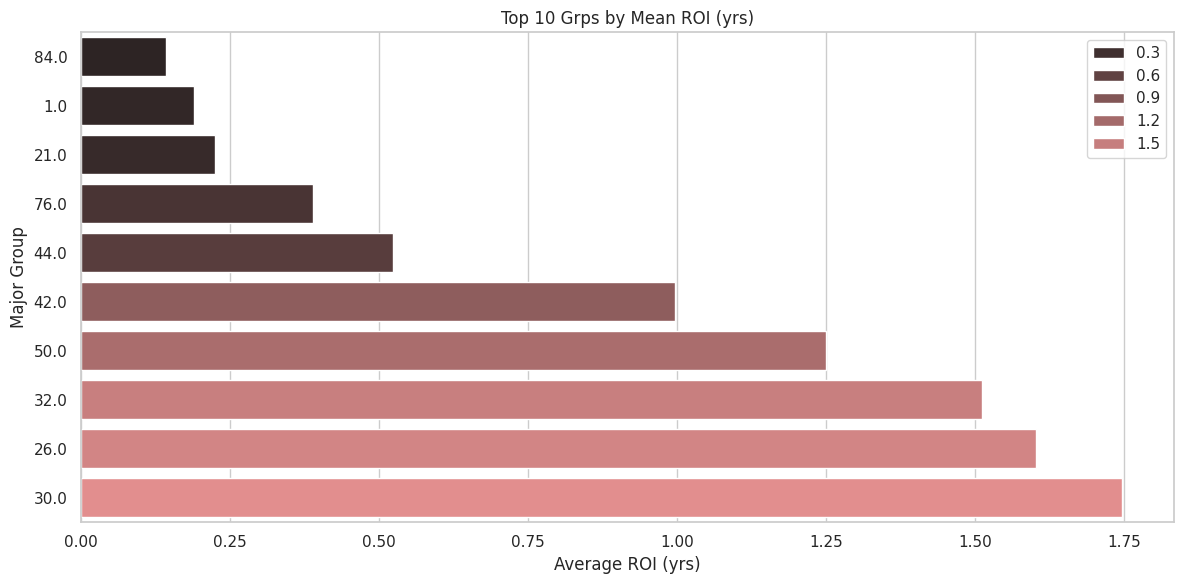

In [ ]:
# 6) Mean ROI
roi_by_grp_mu = (
    work_data
    .groupby('Major Group')['ROI(yrs)']
    .mean()
    .nsmallest(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=roi_by_grp_mu.values,
    y=roi_by_grp_mu.index.astype(str),
    hue=roi_by_grp_mu.values,
    palette='dark:lightcoral'
)
plt.title("Top 10 Grps by Mean ROI (yrs)")
plt.xlabel("Average ROI (yrs)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


*Top 10 SIC codes*

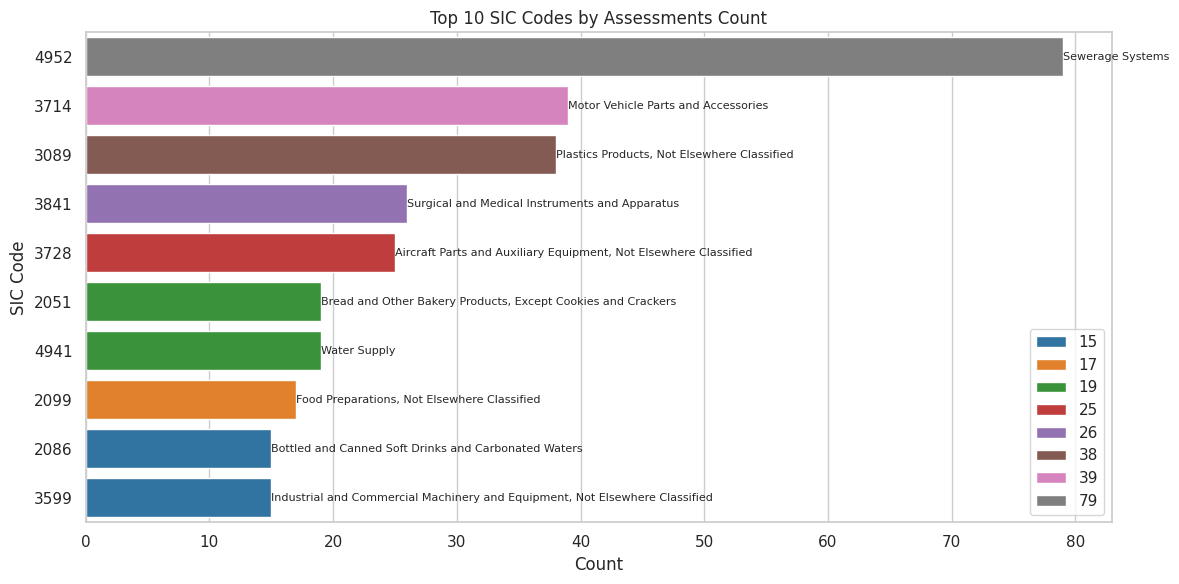

In [ ]:

sic_counts = work_data['SIC'].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=sic_counts.values, y=sic_counts.index.astype(str),hue = sic_counts.values, palette='tab10')
plt.title("Top 10 SIC Codes by Assessments Count")
plt.xlabel("Count")
plt.ylabel("SIC Code")

for i,(code,val) in enumerate(zip(sic_counts.index, sic_counts.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()


*Top 10 Industries by Savings*

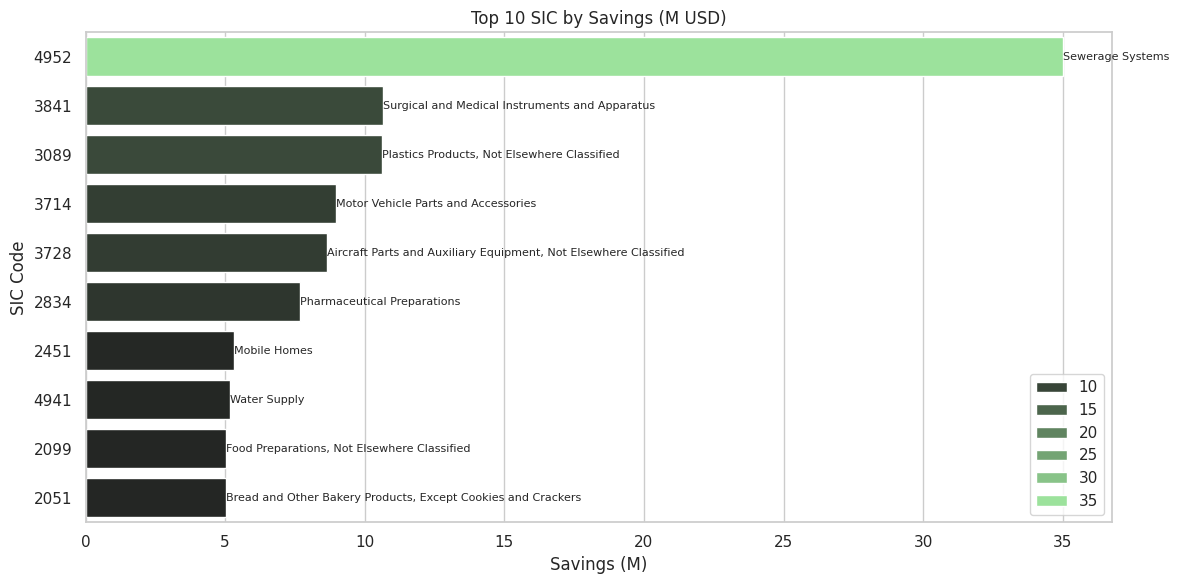

In [ ]:
savings_by_sic = (work_data
                  .groupby('SIC')['Savings(M)']
                  .sum()
                  .nlargest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=savings_by_sic.values, y=savings_by_sic.index.astype(str),hue = savings_by_sic.values, palette='dark:lightgreen')
plt.title("Top 10 SIC by Savings (M USD)")
plt.xlabel("Savings (M)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(savings_by_sic.index, savings_by_sic.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()


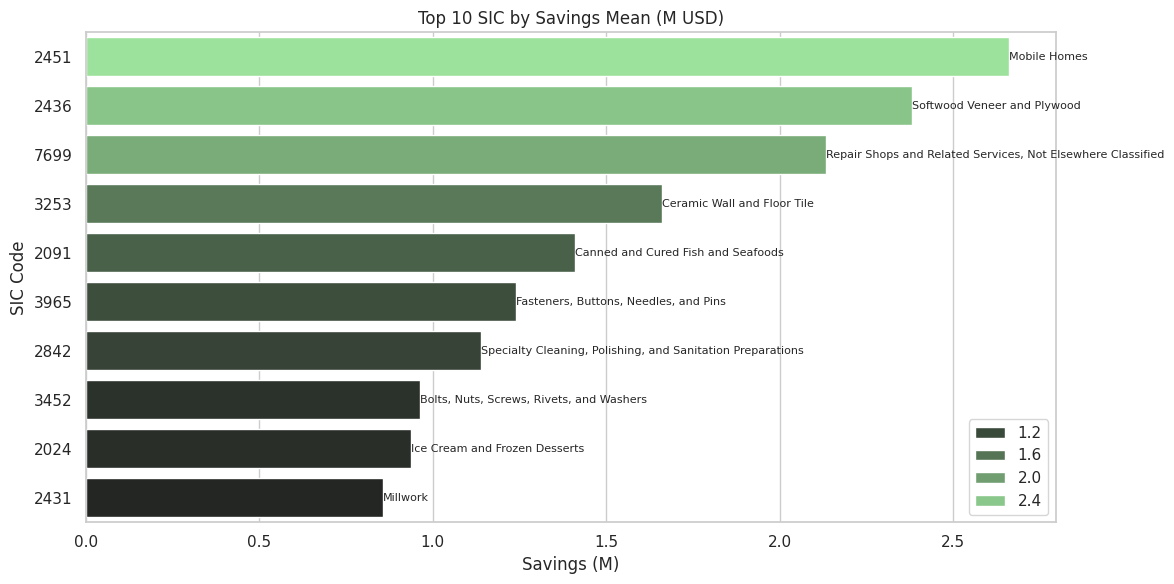

In [ ]:
savings_by_sic_mu = (work_data
                  .groupby('SIC')['Savings(M)']
                  .mean()
                  .nlargest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=savings_by_sic_mu.values, y=savings_by_sic_mu.index.astype(str),hue = savings_by_sic_mu.values, palette='dark:lightgreen')
plt.title("Top 10 SIC by Savings Mean (M USD)")
plt.xlabel("Savings (M)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(savings_by_sic_mu.index, savings_by_sic_mu.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()

*Top 10 Industries by Electricity Costs*

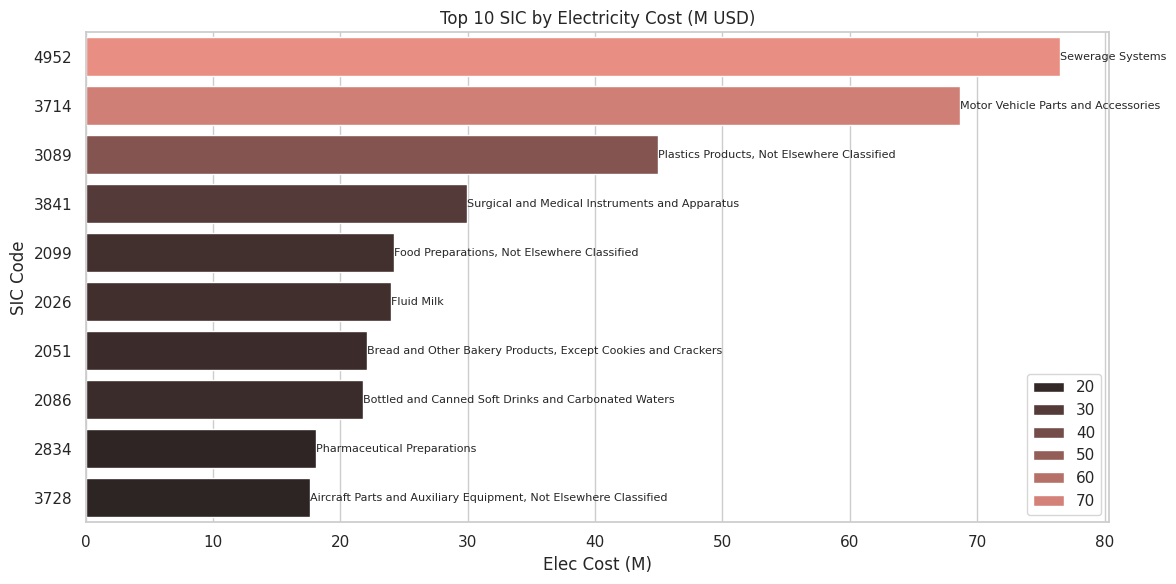

In [ ]:
elec_by_sic = (work_data
               .groupby('SIC')['AnnualElec(M)']
               .sum()
               .nlargest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=elec_by_sic.values, y=elec_by_sic.index.astype(str),hue = elec_by_sic.values, palette='dark:salmon')
plt.title("Top 10 SIC by Electricity Cost (M USD)")
plt.xlabel("Elec Cost (M)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(elec_by_sic.index, elec_by_sic.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()


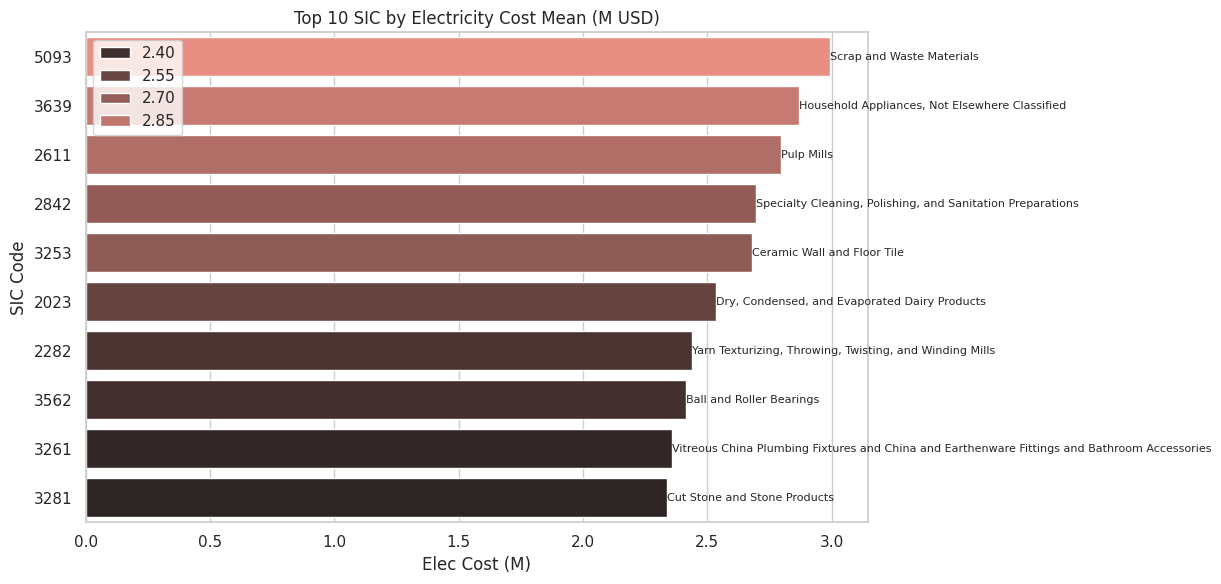

In [ ]:

elec_by_sic_mu = (work_data
               .groupby('SIC')['AnnualElec(M)']
               .mean()
               .nlargest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=elec_by_sic_mu.values, y=elec_by_sic_mu.index.astype(str),hue = elec_by_sic_mu.values, palette='dark:salmon')
plt.title("Top 10 SIC by Electricity Cost Mean (M USD)")
plt.xlabel("Elec Cost (M)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(elec_by_sic_mu.index, elec_by_sic_mu.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()

*Top 10 Industries by ROI Yrs*

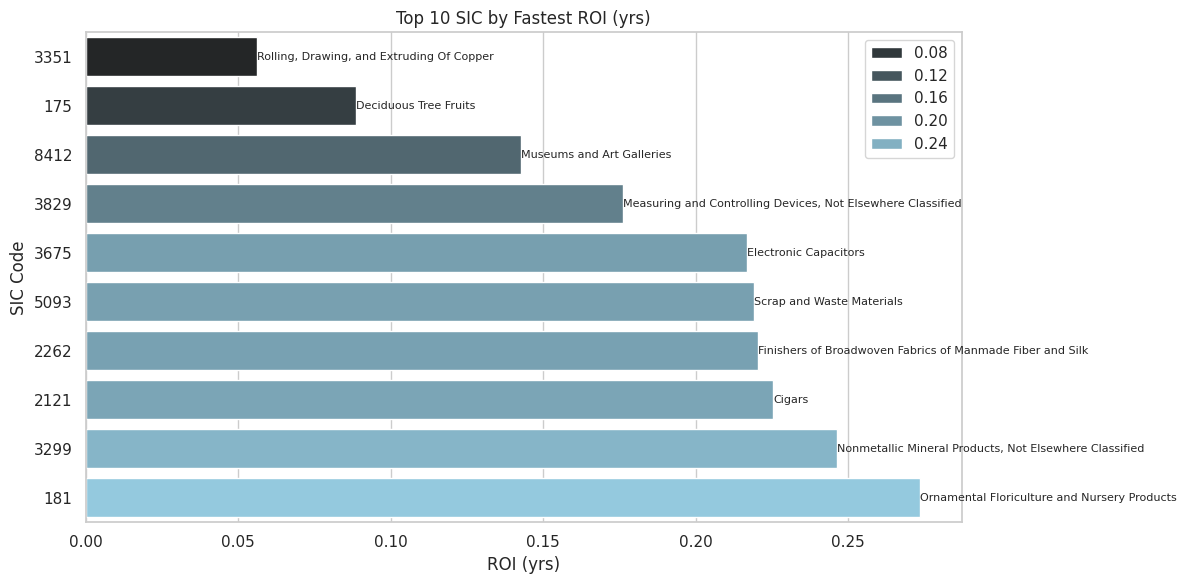

In [ ]:
roi_by_sic = (work_data
              .groupby('SIC')['ROI(yrs)']
              .mean()
              .nsmallest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=roi_by_sic.values, y=roi_by_sic.index.astype(str),hue = roi_by_sic.values, palette='dark:skyblue' )
plt.title("Top 10 SIC by Fastest ROI (yrs)")
plt.xlabel("ROI (yrs)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(roi_by_sic.index, roi_by_sic.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
top_10_industry_df = pd.DataFrame({
    'Major Group':      mg_counts.index.astype(str),

    'SIC Code':         sic_counts.index.astype(int),
    'SIC Industry':     [sic_lookup[s] for s in sic_counts.index],

    'Savings Code':     savings_by_sic.index.astype(int),
    'Savings Industry': [sic_lookup[s] for s in savings_by_sic.index],

    'Mean Savings Code':     savings_by_sic_mu.index.astype(int),
    'Mean Savings Industry': [sic_lookup[s] for s in savings_by_sic_mu.index],

    'ElecCost Code':    elec_by_sic.index.astype(int),
    'ElecCost Industry':[sic_lookup[s] for s in elec_by_sic.index],

    'Mean ElecCost Code':    elec_by_sic_mu.index.astype(int),
    'Mean ElecCost Industry':[sic_lookup[s] for s in elec_by_sic_mu.index],

    'ROI Code':         roi_by_sic.index.astype(int),
    'ROI Industry':     [sic_lookup[s] for s in roi_by_sic.index],
})
top_10_industry_df



,Major Group,SIC Code,SIC Industry,Savings Code,Savings Industry,Mean Savings Code,Mean Savings Industry,ElecCost Code,ElecCost Industry,Mean ElecCost Code,Mean ElecCost Industry,ROI Code,ROI Industry
0,20.0,4952,Sewerage Systems,4952,Sewerage Systems,2451,Mobile Homes,4952,Sewerage Systems,5093,Scrap and Waste Materials,3351,"Rolling, Drawing, and Extruding Of Copper"
1,49.0,3714,Motor Vehicle Parts and Accessories,3841,Surgical and Medical Instruments and Apparatus,2436,Softwood Veneer and Plywood,3714,Motor Vehicle Parts and Accessories,3639,"Household Appliances, Not Elsewhere Classified",175,Deciduous Tree Fruits
2,30.0,3089,"Plastics Products, Not Elsewhere Classified",3089,"Plastics Products, Not Elsewhere Classified",7699,"Repair Shops and Related Services, Not Elsewhe...",3089,"Plastics Products, Not Elsewhere Classified",2611,Pulp Mills,8412,Museums and Art Galleries
3,34.0,3841,Surgical and Medical Instruments and Apparatus,3714,Motor Vehicle Parts and Accessories,3253,Ceramic Wall and Floor Tile,3841,Surgical and Medical Instruments and Apparatus,2842,"Specialty Cleaning, Polishing, and Sanitation ...",3829,"Measuring and Controlling Devices, Not Elsewhe..."
4,37.0,3728,"Aircraft Parts and Auxiliary Equipment, Not El...",3728,"Aircraft Parts and Auxiliary Equipment, Not El...",2091,Canned and Cured Fish and Seafoods,2099,"Food Preparations, Not Elsewhere Classified",3253,Ceramic Wall and Floor Tile,3675,Electronic Capacitors
5,28.0,2051,"Bread and Other Bakery Products, Except Cookie...",2834,Pharmaceutical Preparations,3965,"Fasteners, Buttons, Needles, and Pins",2026,Fluid Milk,2023,"Dry, Condensed, and Evaporated Dairy Products",5093,Scrap and Waste Materials
6,35.0,4941,Water Supply,2451,Mobile Homes,2842,"Specialty Cleaning, Polishing, and Sanitation ...",2051,"Bread and Other Bakery Products, Except Cookie...",2282,"Yarn Texturizing, Throwing, Twisting, and Wind...",2262,Finishers of Broadwoven Fabrics of Manmade Fib...
7,33.0,2099,"Food Preparations, Not Elsewhere Classified",4941,Water Supply,3452,"Bolts, Nuts, Screws, Rivets, and Washers",2086,Bottled and Canned Soft Drinks and Carbonated ...,3562,Ball and Roller Bearings,2121,Cigars
8,38.0,2086,Bottled and Canned Soft Drinks and Carbonated ...,2099,"Food Preparations, Not Elsewhere Classified",2024,Ice Cream and Frozen Desserts,2834,Pharmaceutical Preparations,3261,Vitreous China Plumbing Fixtures and China and...,3299,"Nonmetallic Mineral Products, Not Elsewhere Cl..."
9,36.0,3599,Industrial and Commercial Machinery and Equipm...,2051,"Bread and Other Bakery Products, Except Cookie...",2431,Millwork,3728,"Aircraft Parts and Auxiliary Equipment, Not El...",3281,Cut Stone and Stone Products,181,Ornamental Floriculture and Nursery Products


*Industries that make it along most dimensional studies*

In [ ]:
primary_cols = [
    'SIC Industry',
    'Savings Industry',
    'ElecCost Industry',
    'ROI Industry'
]
all_cols = primary_cols + [
    'Mean Savings Industry',
    'Mean ElecCost Industry'
]

inds = set()
for col in all_cols:
    inds.update(top_10_industry_df[col].dropna().unique())

counts_no_mean = {
    ind: sum(ind in top_10_industry_df[col].values for col in primary_cols)
    for ind in inds
}

counts_with_mean = {
    ind: sum(ind in top_10_industry_df[col].values for col in all_cols)
    for ind in inds
}

at_least_3 = sorted([ind for ind, cnt in counts_no_mean.items() if cnt >= 3])
at_least_4_with_mean = sorted([ind for ind, cnt in counts_with_mean.items() if cnt >= 4])

# 6. Print results
print("Industries in ≥3 of the 4 primary metrics (SIC, Savings, Cost, ROI):")
for ind in at_least_3:
    print(" -", ind)

print("\nIndustries in ≥4 of the 6 metrics (including mean Savings & mean Cost):")
for ind in at_least_4_with_mean:
    print(" -", ind)


Industries in ≥3 of the 4 primary metrics (SIC, Savings, Cost, ROI):
 - Aircraft Parts and Auxiliary Equipment, Not Elsewhere Classified
 - Bread and Other Bakery Products, Except Cookies and Crackers
 - Food Preparations, Not Elsewhere Classified
 - Motor Vehicle Parts and Accessories
 - Plastics Products, Not Elsewhere Classified
 - Sewerage Systems
 - Surgical and Medical Instruments and Apparatus

Industries in ≥4 of the 6 metrics (including mean Savings & mean Cost):


#Sector Wise Analysis#

In [ ]:
def sector_analysis(sic_code: int, df: pd.DataFrame):
    desc_lookup = df.drop_duplicates('SIC').set_index('SIC')['Description']
    industry = desc_lookup.get(sic_code, "Unknown Industry")
    print(f"\nSector {sic_code}: {industry}")
    raw = {
        'ANNUAL_SALES':            ('Annual Sales (M)',        1e6),
        'EMPLOYEES':               ('Employees',               1),
        'PLANT_AREA':              ('Plant Area (M sqft)',     1e6),
        'ANNUAL_ELECTRICITY_COST': ('Electricity Cost (M)',    1e6),
        'TOTAL_RECC_IMP_COST':     ('Implementation Cost (M)', 1e6),
        'TOTAL_RECC_SAVINGS':      ('Savings (M)',             1e6),
        'ROI_YRS':                 ('ROI (yrs)',               1),
    }
    cols = [c for c in raw if c in df.columns]
    sect = df[df['SIC'] == sic_code][cols].copy()
    if sect.empty:
        print("No data for this SIC.")
        return
    sect_scaled = pd.DataFrame({
        label: sect[col] / scale
        for col, (label, scale) in raw.items() if col in sect
    })
    stats = sect_scaled.describe().T[['count','mean','std','25%','50%','75%']]
    print(f"{industry} Summary (scaled)")
    display(stats)

    global_scaled = pd.DataFrame({
        label: df[col] / scale
        for col, (label, scale) in raw.items() if col in df
    })
    gmean = global_scaled.mean()
    gmed  = global_scaled.median()

    comp = pd.DataFrame({
        'Sector Mean':   stats['mean'],
        'Global Mean':   gmean,
        'Mean Diff':     stats['mean']   - gmean,
        'Sector Median': stats['50%'],
        'Global Median': gmed,
        'Median Diff':   stats['50%']    - gmed,
    }).rename(columns={
        'Sector Mean':   f'{industry} Mean',
        'Sector Median': f'{industry} Median'
    })

    print(f"{industry} VS Global Comparison")
    display(comp)


    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    for ax, col in zip(axes, sect_scaled.columns):
        sns.histplot(sect_scaled[col], kde=True, ax=ax,
                     color='orange', edgecolor='black', alpha=0.6)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.set_ylabel('Count')
    if len(sect_scaled.columns) < len(axes):
        fig.delaxes(axes[-1])
    plt.tight_layout()
    plt.show()

    for metric in comp.index:
        cols_to_plot = [
            'Global Mean',
            f'{industry} Mean',
            'Global Median',
            f'{industry} Median'
        ]
        vals = comp.loc[metric, cols_to_plot]
        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(cols_to_plot, vals.values,
                      color=['gray','orange','lightgray','salmon'],
                      edgecolor='black')
        ax.set_title(f"{metric}: Global vs. {industry}")
        ax.set_ylabel(metric)
        ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2, v*1.01,
                    f"{v:.2f}", ha='center', va='bottom', fontsize=8)
        plt.tight_layout()
        plt.show()




Sector 4952: Sewerage Systems
Sewerage Systems Summary (scaled)


,count,mean,std,25%,50%,75%
Annual Sales (M),79.0,12.192115,18.065398,0.453500,8.000000,15.000000
Employees,79.0,37.063291,47.488012,12.000000,19.000000,45.500000
Plant Area (M sqft),79.0,1.071766,1.622819,0.121142,0.609840,1.255260
Electricity Cost (M),79.0,0.968677,0.769612,0.495239,0.631885,1.273132
Implementation Cost (M),79.0,0.920521,1.670387,0.204933,0.456714,0.956169
Savings (M),79.0,0.443140,0.522280,0.152143,0.266363,0.464104
ROI (yrs),79.0,2.010132,1.367642,0.865857,1.921834,2.935623


Sewerage Systems VS Global Comparison


,Sewerage Systems Mean,Global Mean,Mean Diff,Sewerage Systems Median,Global Median,Median Diff
Annual Sales (M),12.192115,74.042556,-61.850441,8.000000,40.000000,-32.000000
Employees,37.063291,182.426513,-145.363222,19.000000,120.000000,-101.000000
Plant Area (M sqft),1.071766,0.378101,0.693665,0.609840,0.155000,0.454840
Electricity Cost (M),0.968677,1.047491,-0.078814,0.631885,0.810231,-0.178346
Implementation Cost (M),0.920521,0.556907,0.363614,0.456714,0.355824,0.100890
Savings (M),0.443140,0.304558,0.138582,0.266363,0.192319,0.074044
ROI (yrs),2.010132,1.935829,0.074303,1.921834,1.633087,0.288748


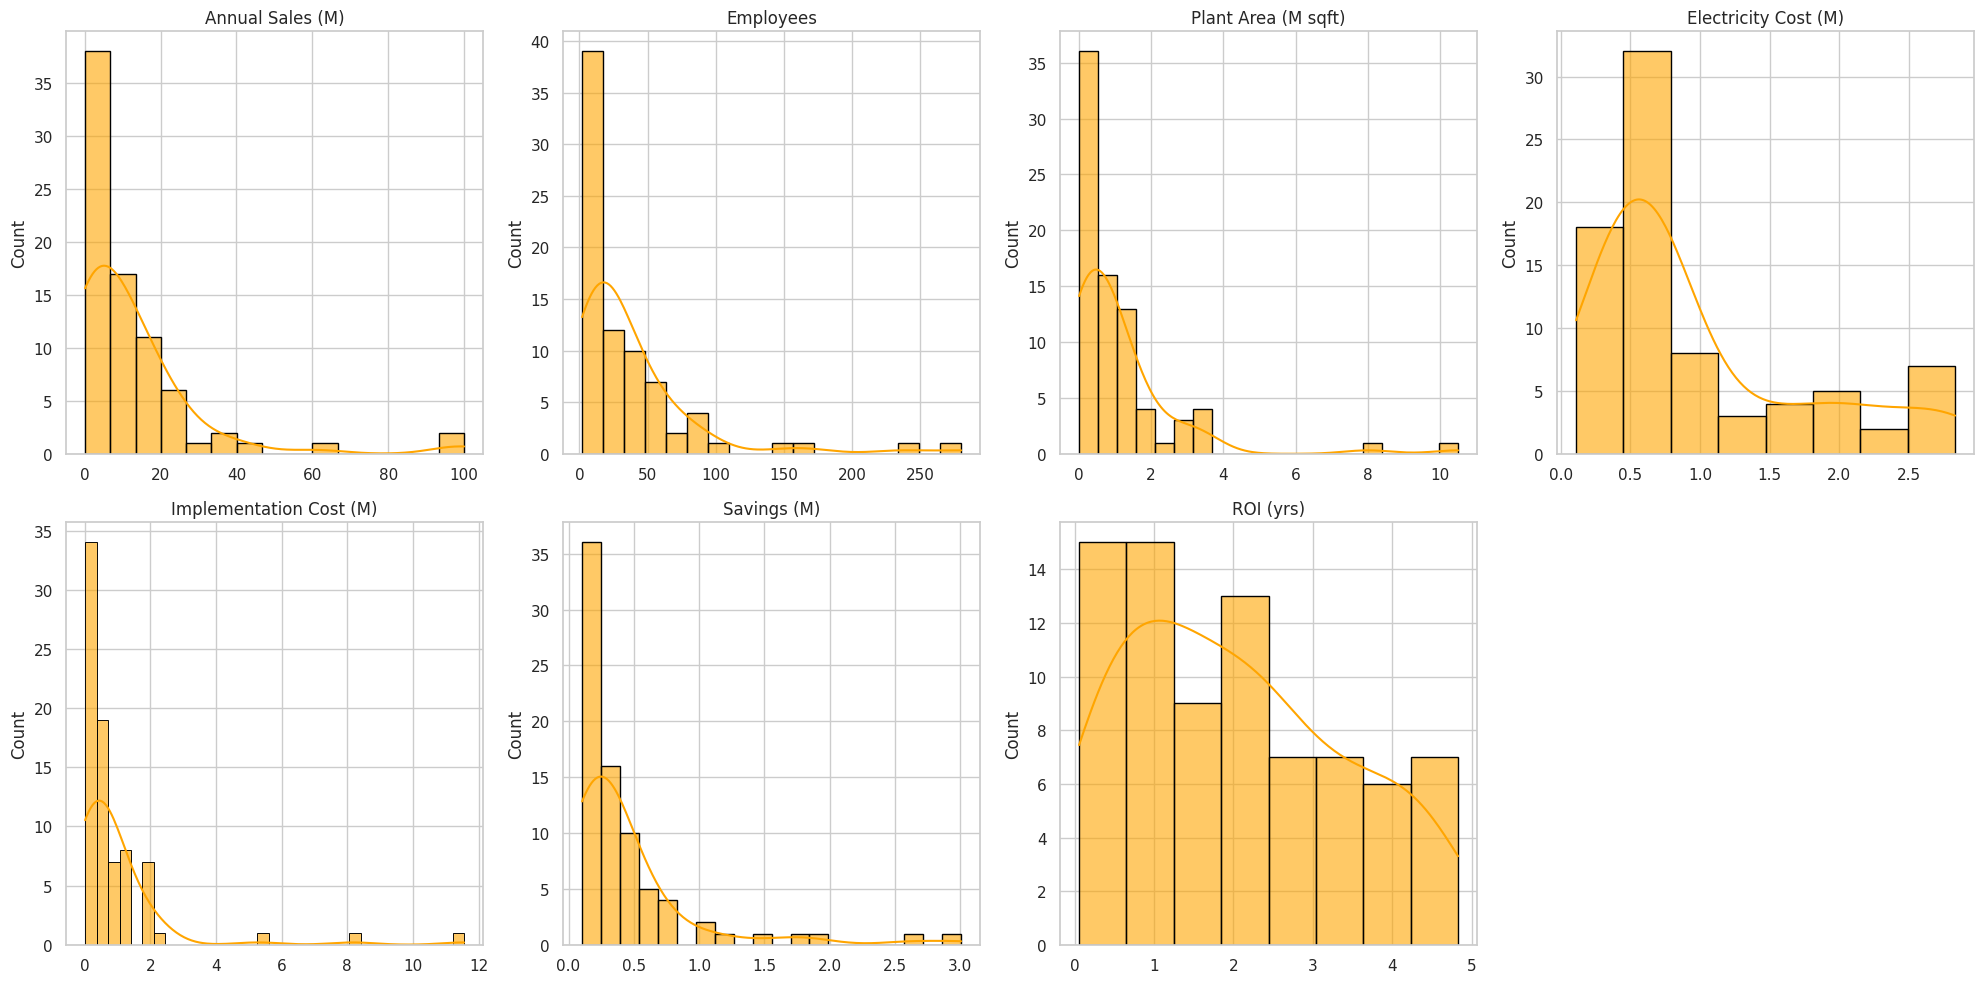

/tmp/ipython-input-33-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


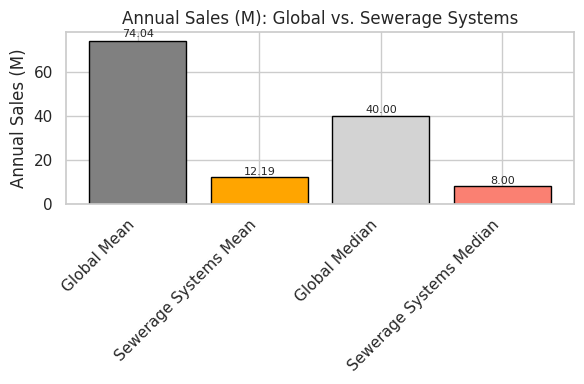

/tmp/ipython-input-33-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


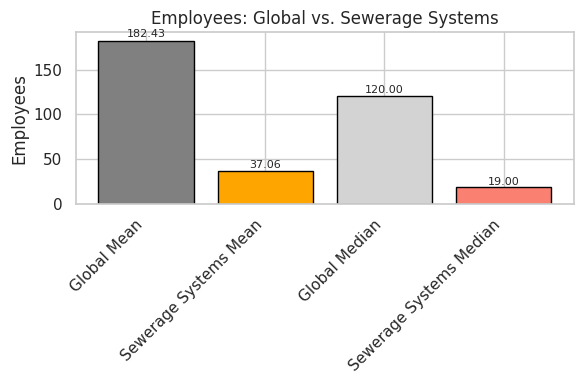

/tmp/ipython-input-33-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


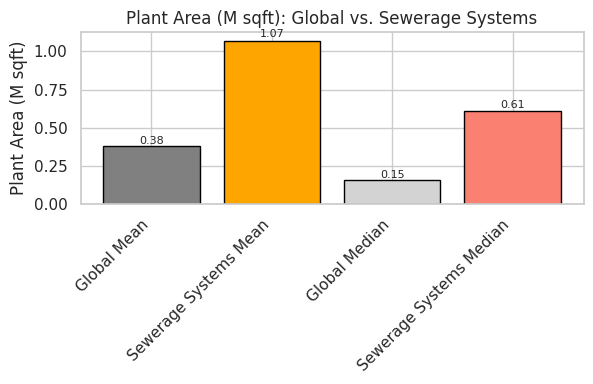

/tmp/ipython-input-33-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


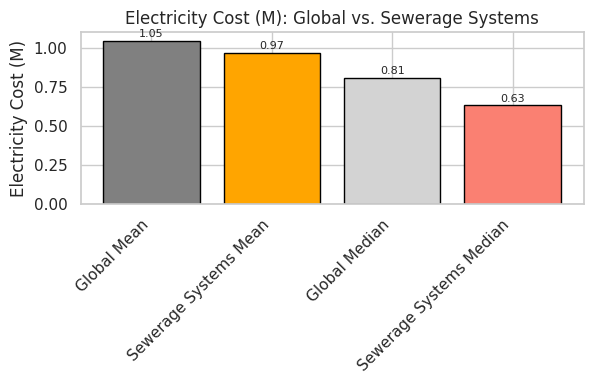

/tmp/ipython-input-33-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


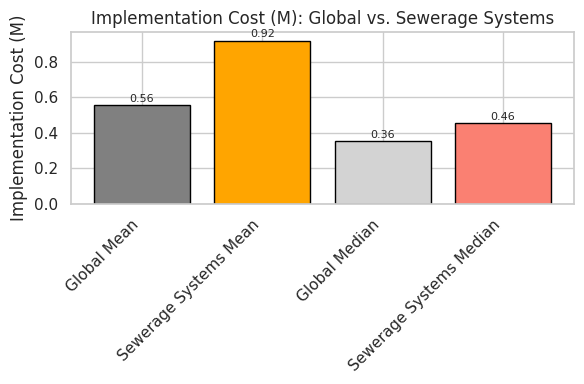

/tmp/ipython-input-33-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


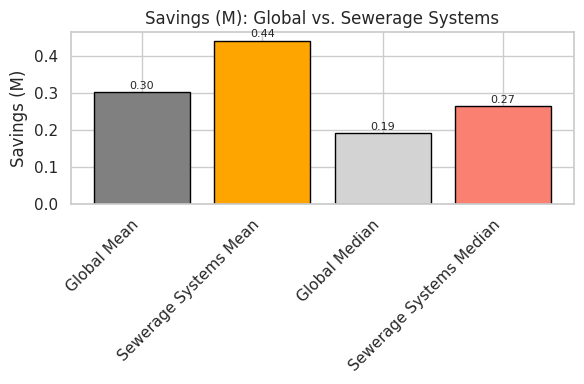

/tmp/ipython-input-33-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


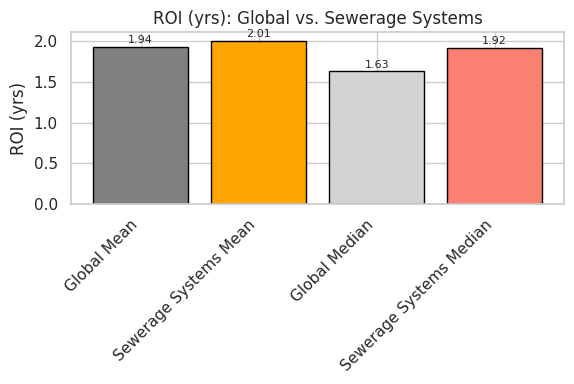

In [ ]:
sector_analysis(4952, df)


#Sector Comparisons#

In [ ]:
def compare_sic_metrics(sic_list, df):
    raw = {
        'ANNUAL_SALES':            ('Annual Sales (M)',        1e6),
        'EMPLOYEES':               ('Employees',               1),
        'PLANT_AREA':              ('Plant Area (M sqft)',     1e6),
        'ANNUAL_ELECTRICITY_COST': ('Electricity Cost (M)',    1e6),
        'TOTAL_RECC_IMP_COST':     ('Implementation Cost (M)', 1e6),
        'TOTAL_RECC_SAVINGS':      ('Savings (M)',             1e6),
        'ROI_YRS':                 ('ROI (yrs)',               1),
    }
    global_scaled = pd.DataFrame({
        label: df[col] / scale
        for col, (label, scale) in raw.items() if col in df
    })
    gmean = global_scaled.mean()
    gmed  = global_scaled.median()

    desc_lookup = df.drop_duplicates('SIC').set_index('SIC')['Description']
    data_means = {'Global': gmean}
    data_meds  = {'Global': gmed}
    for sic in sic_list:
        sect = df[df['SIC'] == sic]
        sect_scaled = pd.DataFrame({
            label: sect[col] / scale
            for col, (label, scale) in raw.items() if col in sect
        })
        industry = desc_lookup.get(sic, str(sic))
        data_means[industry] = sect_scaled.mean()
        data_meds[industry]  = sect_scaled.median()

    means_df   = pd.DataFrame(data_means)
    medians_df = pd.DataFrame(data_meds)

    sns.set_theme(style="whitegrid")
    series_count = len(means_df.columns)
    colors_means = sns.color_palette("tab10", series_count)

    fig, axes = plt.subplots(2, 4, figsize=(24, 14))
    axes = axes.flatten()
    for ax, metric in zip(axes, means_df.index):
        vals = means_df.loc[metric]
        bars = ax.bar(vals.index, vals.values,
                      color=colors_means, edgecolor='black')
        ax.set_title(f"Mean {metric}")
        ax.set_ylabel(metric)
        ax.set_xticklabels(vals.index, rotation=45, ha='right')
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v * 1.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    if len(means_df.index) < len(axes):
        fig.delaxes(axes[-1])
    plt.tight_layout()
    plt.show()

    colors_meds = sns.color_palette("Set2", series_count)

    fig, axes = plt.subplots(2, 4, figsize=(24, 14))
    axes = axes.flatten()
    for ax, metric in zip(axes, medians_df.index):
        vals = medians_df.loc[metric]
        bars = ax.bar(vals.index, vals.values,
                      color=colors_meds, edgecolor='black')
        ax.set_title(f"Median {metric}")
        ax.set_ylabel(metric)
        ax.set_xticklabels(vals.index, rotation=45, ha='right')
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v * 1.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    if len(medians_df.index) < len(axes):
        fig.delaxes(axes[-1])
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-35-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-35-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-35-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-35-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-35-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a

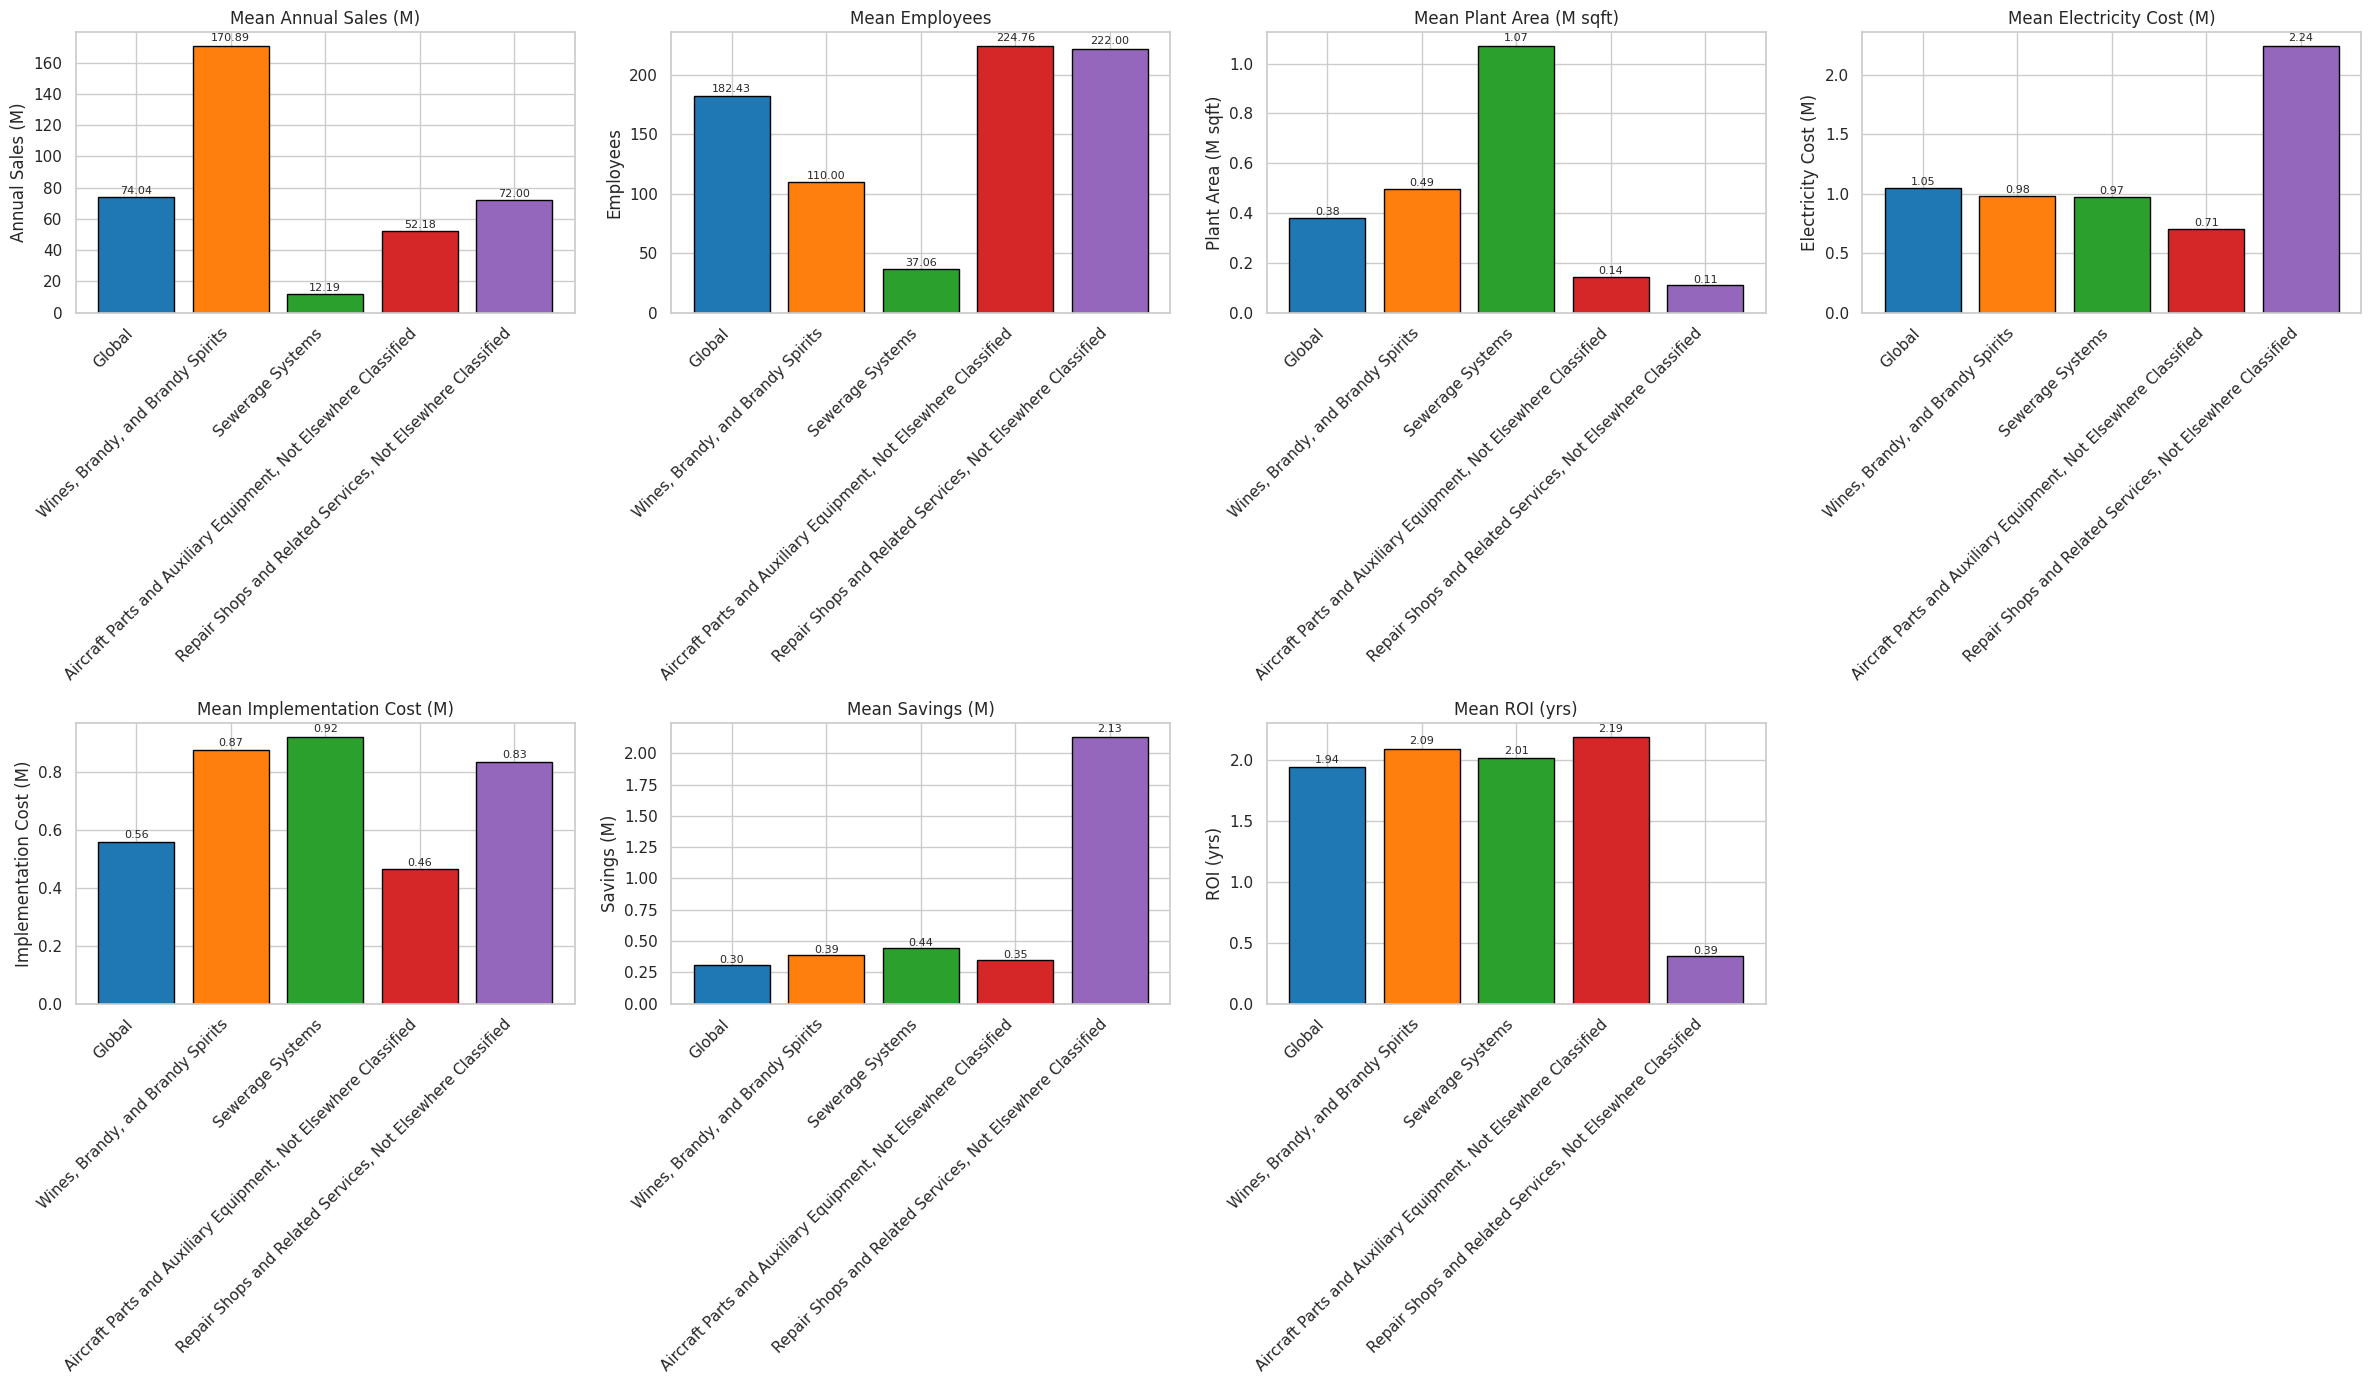

/tmp/ipython-input-35-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-35-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-35-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-35-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-35-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a

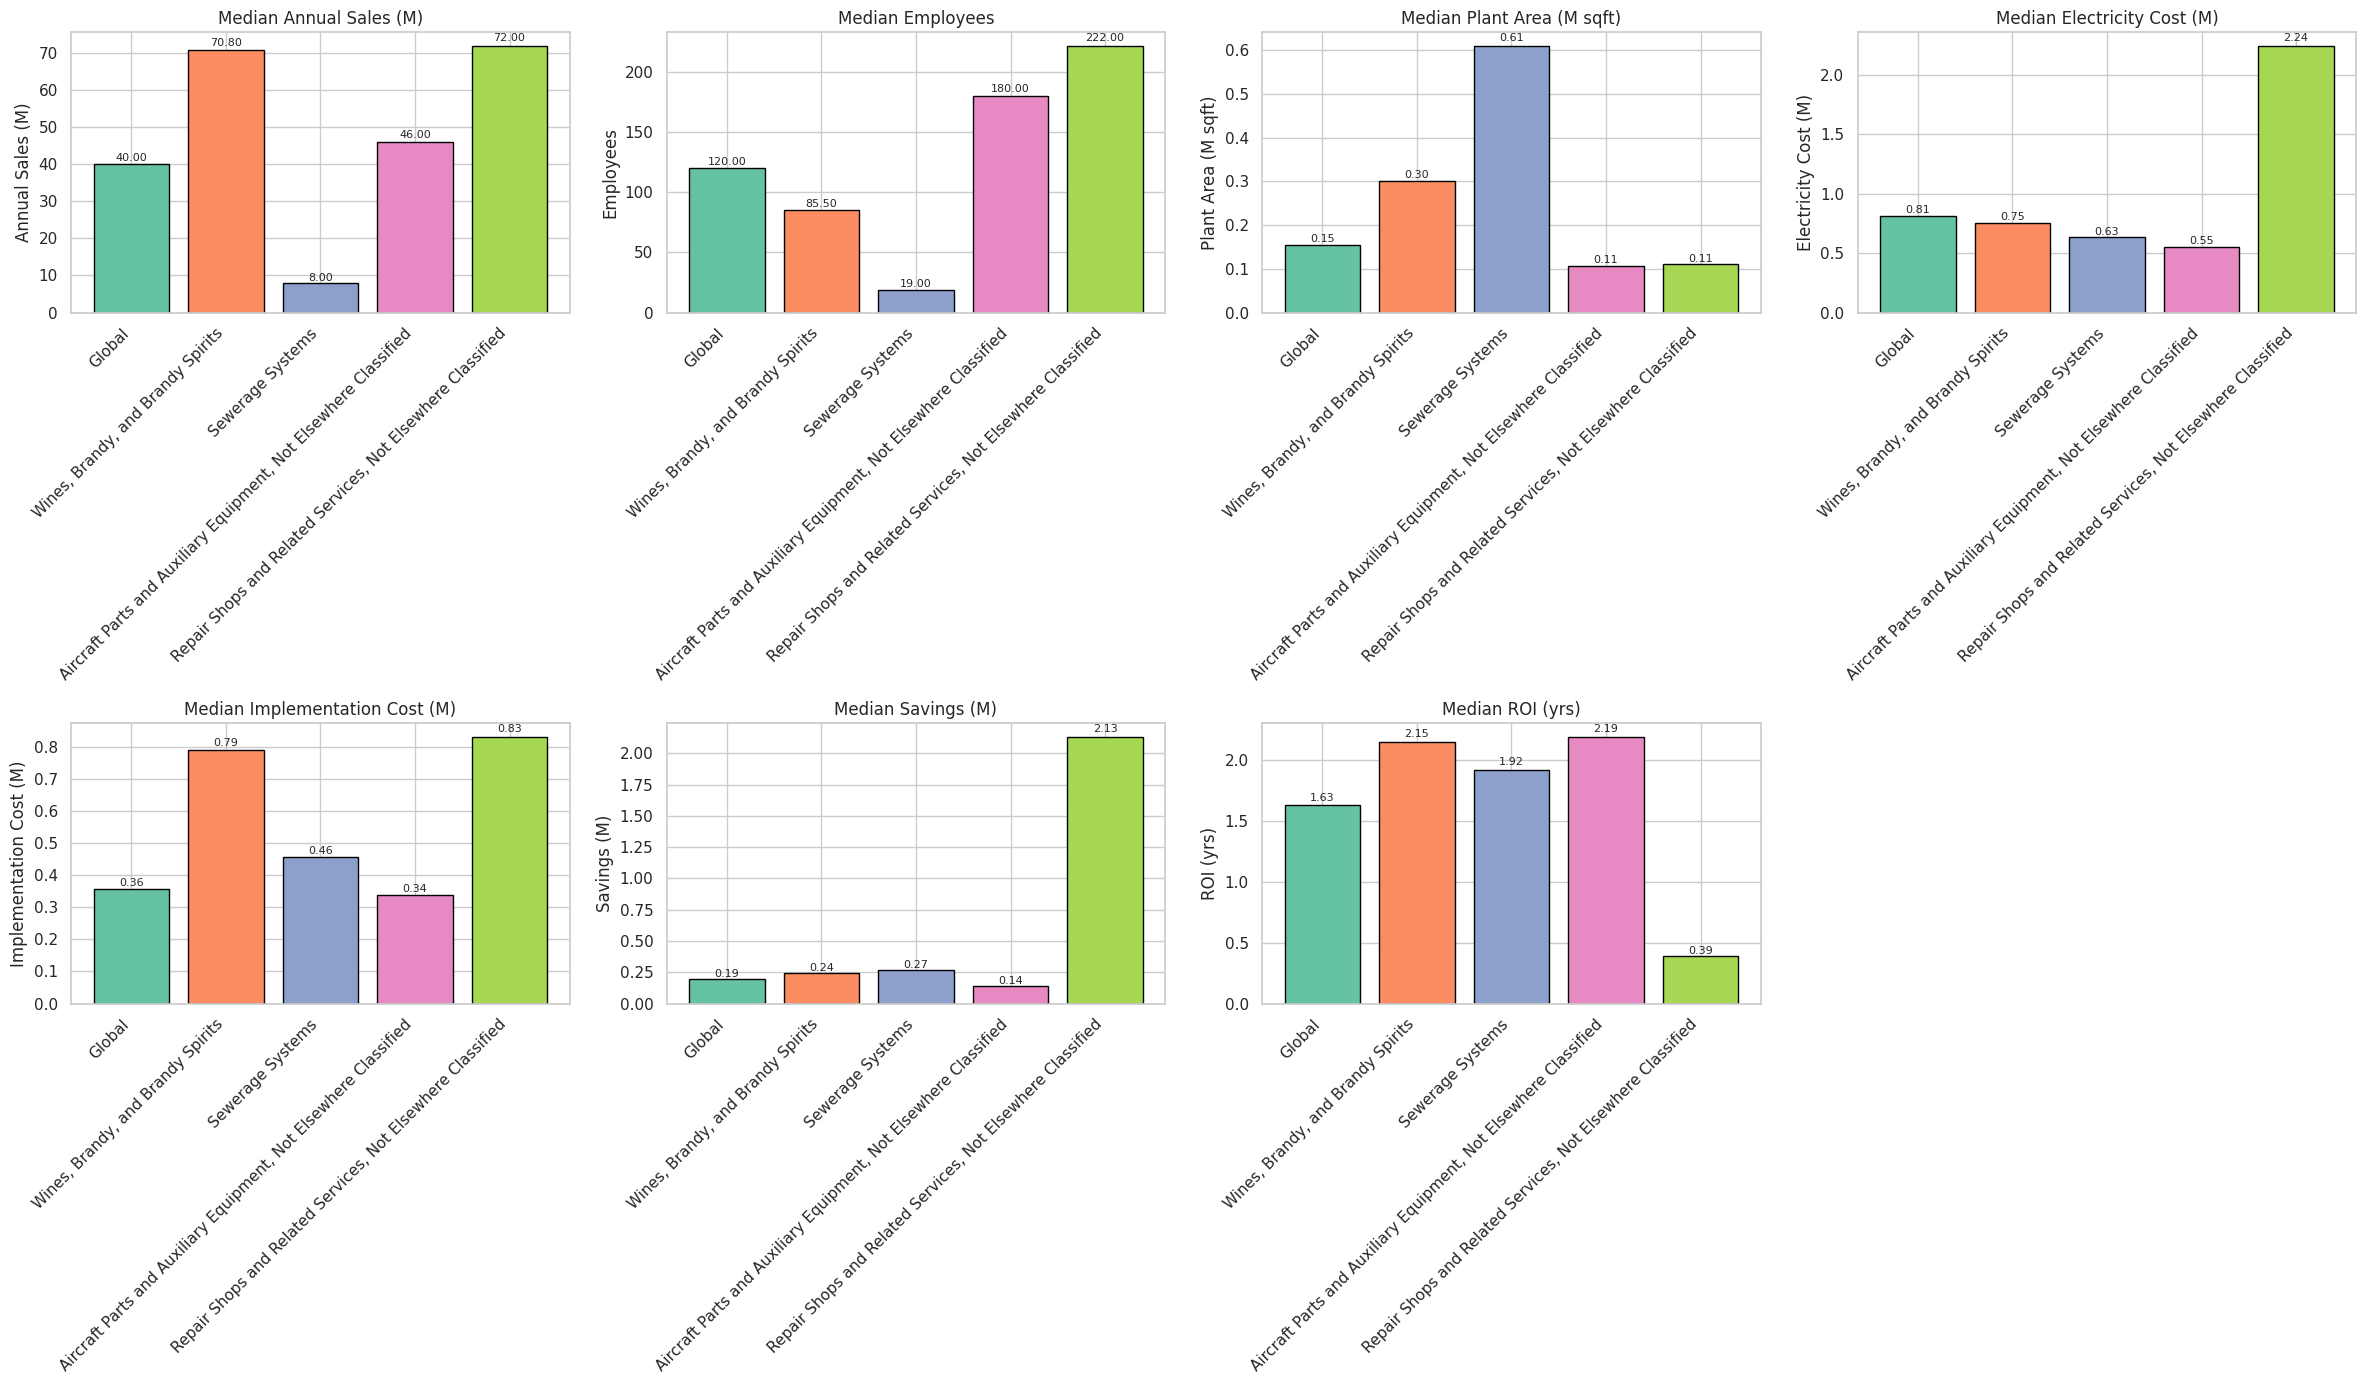

In [ ]:
compare_sic_metrics([2084, 4952, 3728,7699], df)


#Similarity Analysis#

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster import hierarchy
from sklearn.preprocessing import StandardScaler
import textwrap

def similarity_analysis(sic_list, df):
    df_scaled = df.copy()
    for c in ['ANNUAL_SALES','PLANT_AREA',
              'ANNUAL_ELECTRICITY_COST',
              'TOTAL_RECC_IMP_COST',
              'TOTAL_RECC_SAVINGS']:
        df_scaled[c] /= 1e6

    metrics = [
        'ANNUAL_SALES','EMPLOYEES','PLANT_AREA',
        'ANNUAL_ELECTRICITY_COST','TOTAL_RECC_IMP_COST',
        'TOTAL_RECC_SAVINGS','ROI_YRS'
    ]
    rename_map = {
        'ANNUAL_SALES':            'Sales (M)',
        'EMPLOYEES':               'Employees',
        'PLANT_AREA':              'Area (M sqft)',
        'ANNUAL_ELECTRICITY_COST': 'ElecCost (M)',
        'TOTAL_RECC_IMP_COST':     'ImplCost (M)',
        'TOTAL_RECC_SAVINGS':      'Savings (M)',
        'ROI_YRS':                 'ROI (yrs)'
    }
  #Vector of 7 dimensions per feature mean per SIC
    prof = (
        df_scaled[df_scaled['SIC'].isin(sic_list)]
          .groupby('SIC')[metrics]
          .mean()
          .rename(columns=rename_map)
    )

    #Standardise these vectors 1 per industry
    X = StandardScaler().fit_transform(prof.values)
    dist_vec = pdist(X, metric='euclidean')#Compute euclidean distance between these vectors
    linkage = hierarchy.linkage(dist_vec, method='ward')


    desc = df_scaled.drop_duplicates('SIC').set_index('SIC')['Description']
    labels = []
    for sic in prof.index:
        short = textwrap.shorten(desc.get(sic,''), width=25, placeholder='…')
        labels.append(f"{sic}\n{short}")

    plt.figure(figsize=(14,5))
    dn = hierarchy.dendrogram(
        linkage,
        labels=labels,
        orientation='top',
        leaf_rotation=45,
        leaf_font_size=10,
        color_threshold=0
    )
    plt.title("Sector Clustering (Euclidean Ward)")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()
    #Correlation between the 7dim vectros Red means very similar industries,blue is different
    corr = prof.T.corr()
    cg = sns.clustermap(
        corr,
        cmap='vlag',
        center=0,
        linewidths=0.8,
        figsize=(12,12),
        annot=True,
        fmt=".2f",
        annot_kws={'size':8},
        xticklabels=labels,
        yticklabels=labels
    )
    cg.fig.suptitle("Sector Similarity: Pearson Correlation", y=1.02)
    plt.show()


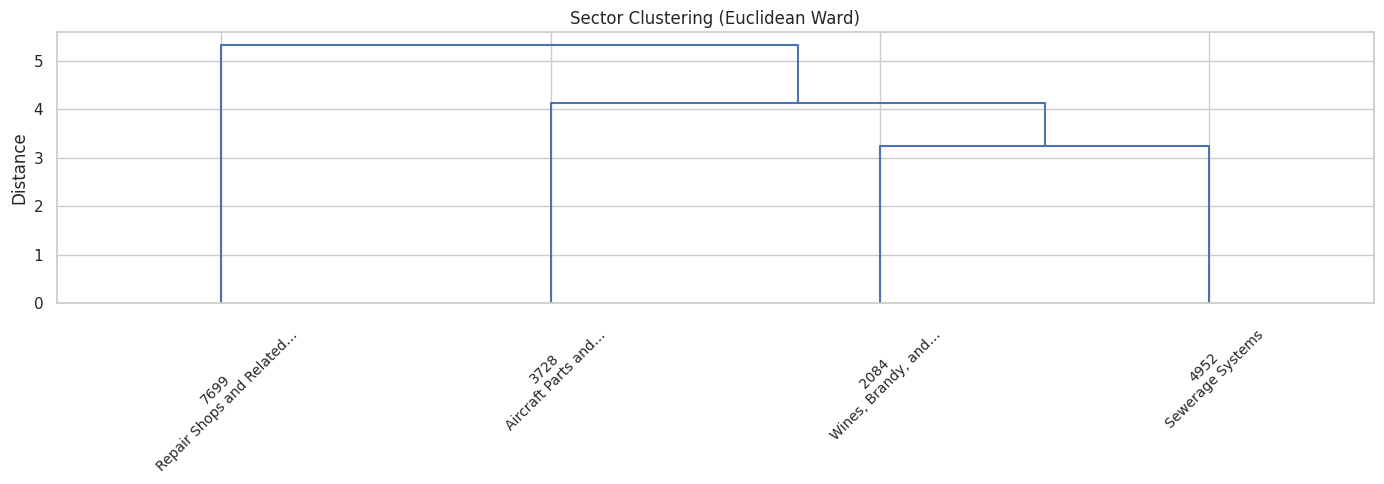

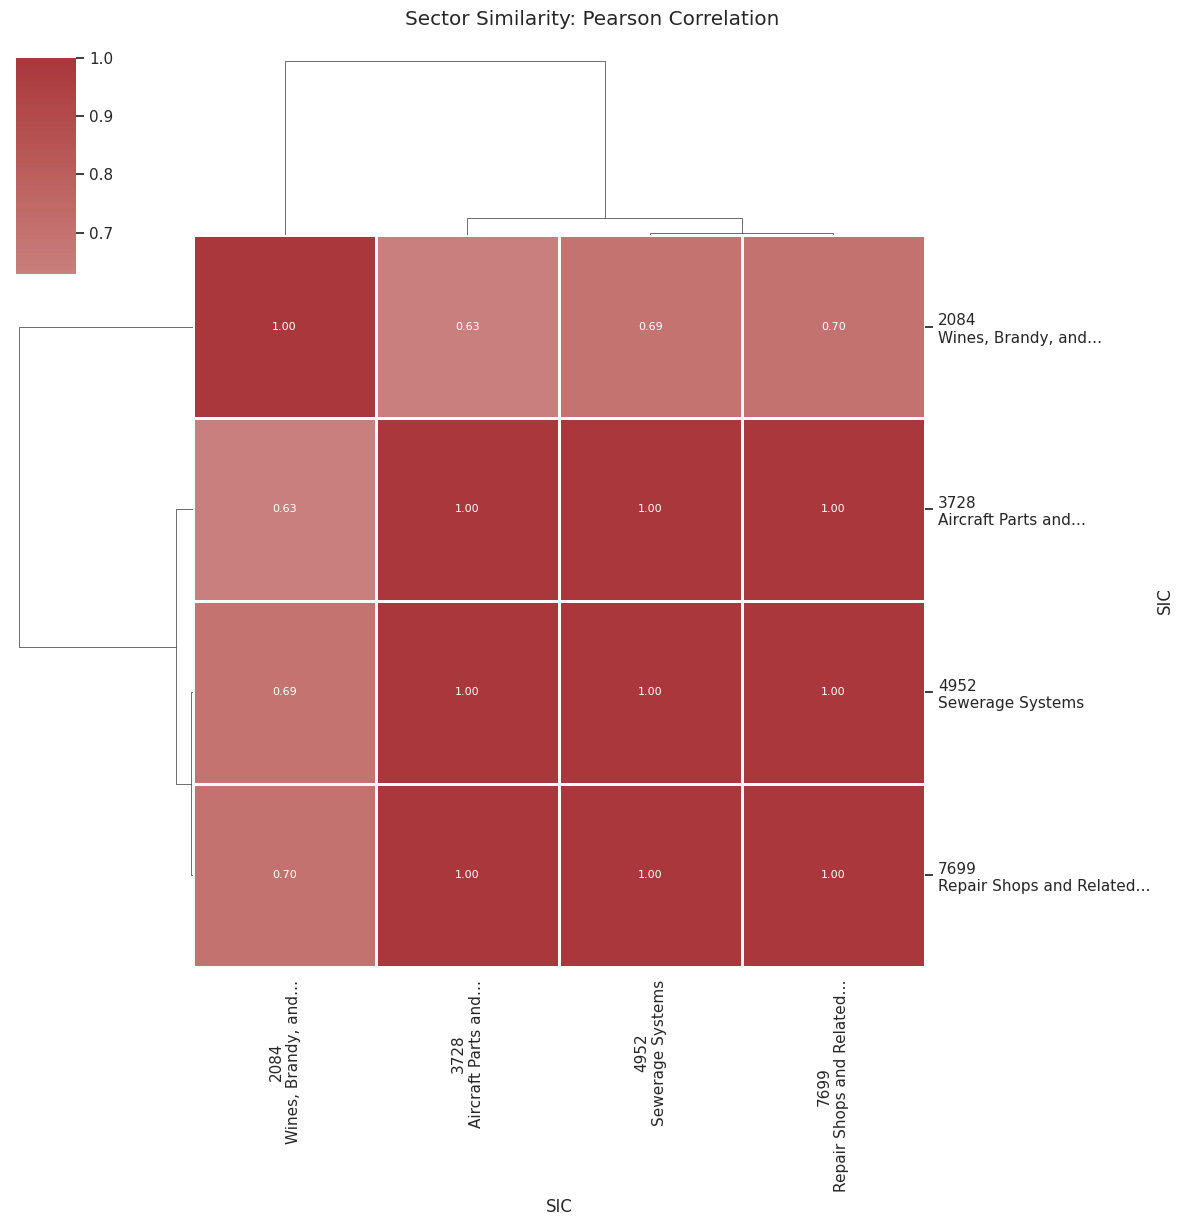

In [ ]:
similarity_analysis([2084, 4952, 3728,7699], df)